# Unified A/B Experiment: Predictive KEDA vs Vanilla HPA (MAX_WORKERS=2, 120 users)

**Round `round_a_mw2_3`** = Vanilla HPA (reactive CPU-threshold)  
**Round `round_b_mw2_3`** = Predictive KEDA (GRU-based pre-scaling)

Configuration:
- `MAX_WORKERS=2` in cpu-service → saturation at ~5 RPS/pod → CPU-queuing regime
- 120 concurrent users (×3 from original A/B)
- 6 load scenarios (same shapes as original A/B)
- Host: `http://192.168.49.2:31413` (NodePort)

This notebook combines:
- **`experiment_results.ipynb`** — CPU saturation, replica analysis, scale-up lag, over-provisioning
- **`stress_results.ipynb`** — Latency under queuing regime, advantage window, phase split

Data sources:
- Locust `stats_history.csv` — per-second latency / RPS
- Prometheus `localhost:9090` — replica count, actual CPU, GRU prediction

In [70]:
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
RESULTS      = Path('../test_deployment/locusts/results')
TIMESTAMPS_F = Path('../test_deployment/locusts/experiment_timestamps.json')
PROM         = 'http://localhost:9091/api/v1/query_range'

# ── Round keys ─────────────────────────────────────────────────────────────
ROUND_HPA  = 'round_a_mw2_3'
ROUND_KEDA = 'round_b_mw2_3'

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLOR_HPA  = 'tomato'      # Vanilla HPA
COLOR_KEDA = 'steelblue'   # Predictive KEDA
COLOR_PRED = 'darkorange'  # GRU prediction
LABEL_HPA  = 'Vanilla HPA'
LABEL_KEDA = 'Predictive KEDA'

SCENARIO_NAMES = [
    '1. Linear Ramp',
    '2. Step Function',
    '3. Sine Wave',
    '4. Multi Spike',
    '5. Random Walk',
    '6. Quiet + Burst',
]

with open(TIMESTAMPS_F) as f:
    timestamps = json.load(f)

print('Setup complete.')
print('Round HPA  scenarios:', list(timestamps[ROUND_HPA].keys()))
print('Round KEDA scenarios:', list(timestamps[ROUND_KEDA].keys()))

Setup complete.
Round HPA  scenarios: ['1. Linear Ramp', '2. Step Function', '3. Sine Wave', '4. Multi Spike', '5. Random Walk', '6. Quiet + Burst']
Round KEDA scenarios: ['1. Linear Ramp', '2. Step Function', '3. Sine Wave', '4. Multi Spike', '5. Random Walk', '6. Quiet + Burst']


---
## 1 — Locust Data: Latency & RPS

In [71]:
# ── Toggle: True = only scenario windows (no idle pauses between scenarios)
#            False = full experiment span (first scenario start → last end)
CLIP_TO_SCENARIOS = True

# Seconds of idle context to include before/after each scenario in per-scenario plots.
# The raw (unclipped) history is used for slicing; active_only is still bounded to [start, end].
IDLE_PAD_S = 30

def load_history(round_id: str) -> pd.DataFrame:
    path = RESULTS / f'round_{round_id}_stats_history.csv'
    df = pd.read_csv(path)
    df = df[df['Name'] == 'Aggregated'].copy()
    for col in ['50%', '95%', '99%', '100%']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.sort_values('Timestamp').reset_index(drop=True)
    return df

def slice_scenario(df: pd.DataFrame, name: str, round_key: str,
                   min_rps: float = 0.5,
                   pad_s: float = IDLE_PAD_S) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (full_window, active_only) with 't' = seconds from scenario start.

    full_window includes pad_s seconds of idle context before/after the scenario
    window so time-series plots show the system state entering and leaving load.
    active_only is bounded to [start, end] with Requests/s > min_rps.
    df should be the unclipped raw history so the padding rows are available.
    """
    ts_info = timestamps[round_key][name]
    start, end = ts_info['start_unix'], ts_info['end_unix']
    mask_full = (df['Timestamp'] >= start - pad_s) & (df['Timestamp'] <= end + pad_s)
    s = df[mask_full].copy()
    s['t'] = s['Timestamp'] - start
    active_mask = (
        (df['Timestamp'] >= start) & (df['Timestamp'] <= end)
    )
    active = df[active_mask].copy()
    active['t'] = active['Timestamp'] - start
    active = active[active['Requests/s'] > min_rps].copy()
    return s, active

def clip_to_scenarios(df: pd.DataFrame, round_key: str) -> pd.DataFrame:
    """Keep only rows within one of the 6 scenario windows (no idle pauses)."""
    combined = pd.Series(False, index=df.index)
    for name in SCENARIO_NAMES:
        ts_info = timestamps[round_key][name]
        combined |= (df['Timestamp'] >= ts_info['start_unix']) & \
                    (df['Timestamp'] <= ts_info['end_unix'])
    return df[combined].reset_index(drop=True)

def clip_to_round(df: pd.DataFrame, round_key: str) -> pd.DataFrame:
    """Keep rows within the full round span (includes idle pauses between scenarios)."""
    starts = [timestamps[round_key][n]['start_unix'] for n in SCENARIO_NAMES]
    ends   = [timestamps[round_key][n]['end_unix']   for n in SCENARIO_NAMES]
    mask = (df['Timestamp'] >= min(starts)) & (df['Timestamp'] <= max(ends))
    return df[mask].reset_index(drop=True)

def align_history(df: pd.DataFrame, round_key: str) -> pd.DataFrame:
    if CLIP_TO_SCENARIOS:
        return clip_to_scenarios(df, round_key)
    return clip_to_round(df, round_key)

# Raw (unclipped) histories — used by slice_scenario so padding rows are available.
hist_hpa_raw  = load_history('a_mw2_3')
hist_keda_raw = load_history('b_mw2_3')

# Clipped histories — used for aggregate stats (boxplot, summary table).
hist_hpa  = align_history(hist_hpa_raw,  ROUND_HPA)
hist_keda = align_history(hist_keda_raw, ROUND_KEDA)

mode = 'scenario windows only' if CLIP_TO_SCENARIOS else 'full round span (idle included)'
print(f'Mode: {mode}')
print(f'Round HPA:  {len(hist_hpa)} rows (clipped)  |  {len(hist_hpa_raw)} rows (raw)')
print(f'Round KEDA: {len(hist_keda)} rows (clipped)  |  {len(hist_keda_raw)} rows (raw)')
print(f'Idle padding: ±{IDLE_PAD_S}s around each scenario in per-scenario plots')

Mode: scenario windows only
Round HPA:  3712 rows (clipped)  |  5211 rows (raw)
Round KEDA: 3714 rows (clipped)  |  5211 rows (raw)
Idle padding: ±30s around each scenario in per-scenario plots


### Table 1 — Request Latency per Scenario

All values are medians over active period (Requests/s > 0.5).  
At MAX_WORKERS=2 and 120 users, expect significant P50 difference (cf. stress test: HPA=2000ms, KEDA=880ms).

In [72]:
def safe(df, col, fn):
    return int(fn(df[col])) if not df.empty and df[col].notna().any() else 'N/A'

rows = []
for name in SCENARIO_NAMES:
    _, act_h = slice_scenario(hist_hpa_raw,  name, ROUND_HPA)
    _, act_k = slice_scenario(hist_keda_raw, name, ROUND_KEDA)
    rows.append({
        'Scenario':   name,
        'HPA P50':    safe(act_h, '50%', pd.Series.median),
        'HPA P95':    safe(act_h, '95%', pd.Series.median),
        'HPA P99med': safe(act_h, '99%', pd.Series.median),
        'HPA P99max': safe(act_h, '99%', pd.Series.max),
        'KEDA P50':   safe(act_k, '50%', pd.Series.median),
        'KEDA P95':   safe(act_k, '95%', pd.Series.median),
        'KEDA P99med':safe(act_k, '99%', pd.Series.median),
        'KEDA P99max':safe(act_k, '99%', pd.Series.max),
    })

lat_df = pd.DataFrame(rows).set_index('Scenario')

print('=== Latency (ms): Vanilla HPA vs Predictive KEDA ===')
print(f'{"":<22}  {"── Vanilla HPA ──":^38}  {"── Pred. KEDA ──":^38}')
print(f'{"Scenario":<22}  {"P50":>7} {"P95":>8} {"P99med":>8} {"P99max":>8}  '
      f'{"P50":>7} {"P95":>8} {"P99med":>8} {"P99max":>8}')
print('-' * 100)
for name, r in lat_df.iterrows():
    print(f'{name:<22}  {str(r["HPA P50"]):>7} {str(r["HPA P95"]):>8} '
          f'{str(r["HPA P99med"]):>8} {str(r["HPA P99max"]):>8}  '
          f'{str(r["KEDA P50"]):>7} {str(r["KEDA P95"]):>8} '
          f'{str(r["KEDA P99med"]):>8} {str(r["KEDA P99max"]):>8}')

lat_df

=== Latency (ms): Vanilla HPA vs Predictive KEDA ===
                                  ── Vanilla HPA ──                        ── Pred. KEDA ──           
Scenario                    P50      P95   P99med   P99max      P50      P95   P99med   P99max
----------------------------------------------------------------------------------------------------
1. Linear Ramp             1900     5000     5100     5100      960     4200     4300     4300
2. Step Function           1500     5300     5400     5400      770     4300     5300     5300
3. Sine Wave               1200     5200     5400     5900      380     4200     5300     5400
4. Multi Spike              530     5000     5400     5400      210     4100     5300     5300
5. Random Walk              550     5000     5400     5400      220     4000     5300     5300
6. Quiet + Burst            420     5000     5600     6100      200     3900     5300     6000


,HPA P50,HPA P95,HPA P99med,HPA P99max,KEDA P50,KEDA P95,KEDA P99med,KEDA P99max
Scenario,,,,,,,,
1. Linear Ramp,1900,5000,5100,5100,960,4200,4300,4300
2. Step Function,1500,5300,5400,5400,770,4300,5300,5300
3. Sine Wave,1200,5200,5400,5900,380,4200,5300,5400
4. Multi Spike,530,5000,5400,5400,210,4100,5300,5300
5. Random Walk,550,5000,5400,5400,220,4000,5300,5300
6. Quiet + Burst,420,5000,5600,6100,200,3900,5300,6000


### Figure — Latency Bar Charts per Scenario (P50 / P95 / P99)

Per-scenario medians over the active load window (Requests/s > 0.5).  
Bottom-right: percentage change of KEDA relative to HPA (negative = KEDA lower).

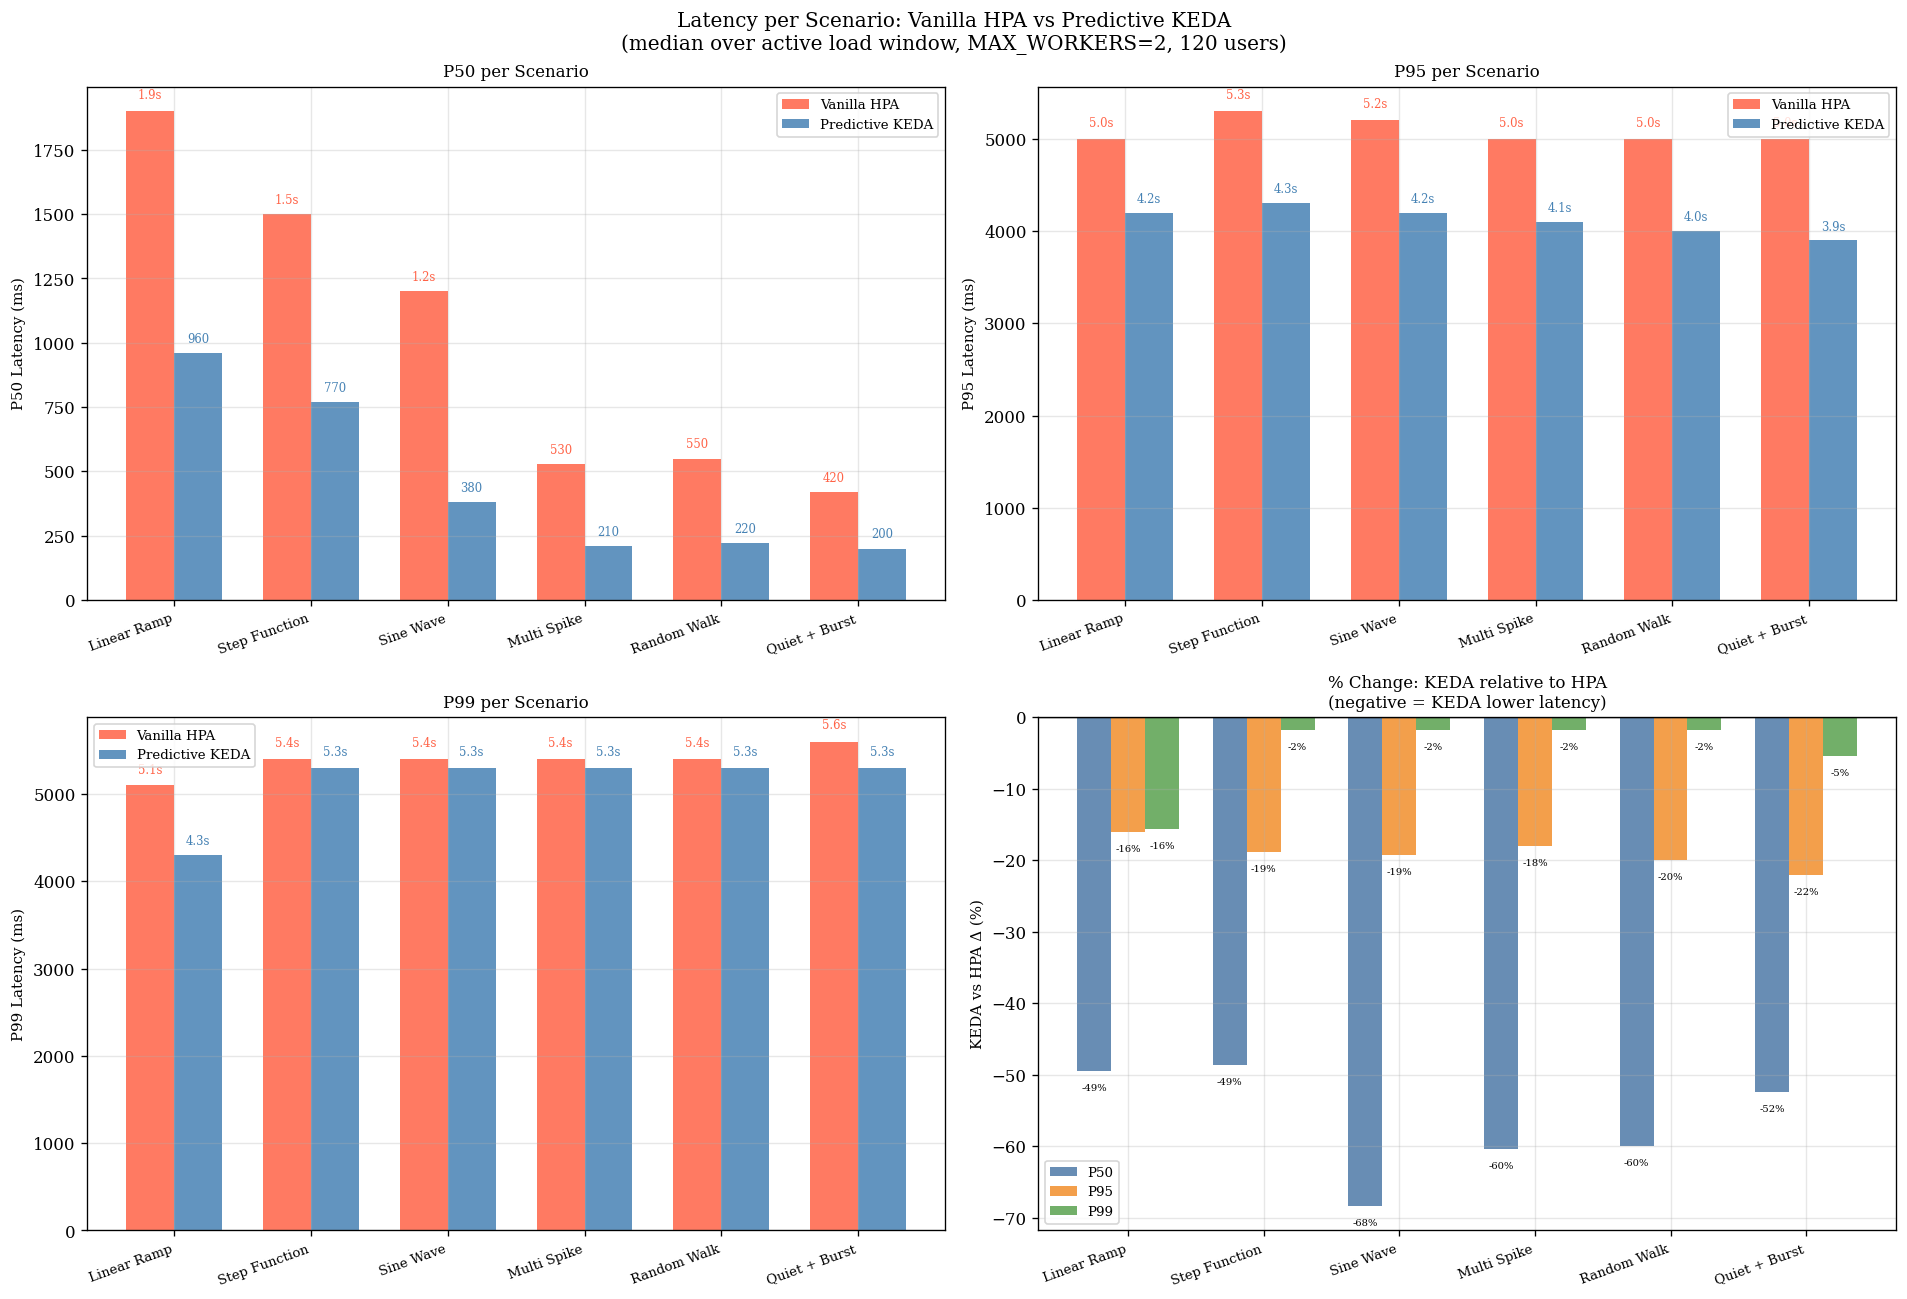

Saved: notebooks/mw2_latency_bars.png


In [73]:
# ── Collect per-scenario medians ───────────────────────────────────────────
bar_rows = []
for name in SCENARIO_NAMES:
    _, act_h = slice_scenario(hist_hpa_raw,  name, ROUND_HPA)
    _, act_k = slice_scenario(hist_keda_raw, name, ROUND_KEDA)
    def _med(df, col):
        return int(df[col].median()) if not df.empty and df[col].notna().any() else 0
    bar_rows.append({
        'short':    name.split('. ', 1)[1],
        'hpa_p50':  _med(act_h, '50%'),  'keda_p50': _med(act_k, '50%'),
        'hpa_p95':  _med(act_h, '95%'),  'keda_p95': _med(act_k, '95%'),
        'hpa_p99':  _med(act_h, '99%'),  'keda_p99': _med(act_k, '99%'),
    })
bar_df = pd.DataFrame(bar_rows)
short_names = bar_df['short'].tolist()
x = np.arange(len(SCENARIO_NAMES))
wb = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Latency per Scenario: Vanilla HPA vs Predictive KEDA\n'
             '(median over active load window, MAX_WORKERS=2, 120 users)', fontsize=12)

for idx, (pct_lbl, h_col, k_col) in enumerate([
    ('P50', 'hpa_p50', 'keda_p50'),
    ('P95', 'hpa_p95', 'keda_p95'),
    ('P99', 'hpa_p99', 'keda_p99'),
]):
    ax = axes.flatten()[idx]
    bh = ax.bar(x - wb/2, bar_df[h_col], wb, color=COLOR_HPA,  alpha=0.85, label=LABEL_HPA)
    bk = ax.bar(x + wb/2, bar_df[k_col], wb, color=COLOR_KEDA, alpha=0.85, label=LABEL_KEDA)
    for bars, col in [(bh, COLOR_HPA), (bk, COLOR_KEDA)]:
        for b in bars:
            v = b.get_height()
            if v > 0:
                lbl = f'{v/1000:.1f}s' if v >= 1000 else f'{v:.0f}'
                ax.text(b.get_x() + b.get_width()/2, v + max(v*0.02, 30),
                        lbl, ha='center', va='bottom', fontsize=7, color=col)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel(f'{pct_lbl} Latency (ms)')
    ax.set_title(f'{pct_lbl} per Scenario')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

# ── Combined: % change KEDA vs HPA ─────────────────────────────────────
ax = axes[1, 1]
pct_pairs = [
    ('P50', 'hpa_p50', 'keda_p50'),
    ('P95', 'hpa_p95', 'keda_p95'),
    ('P99', 'hpa_p99', 'keda_p99'),
]
colors3 = ['#4e79a7', '#f28e2b', '#59a14f']
wb3 = 0.25
for pi, (pct_lbl, h_col, k_col) in enumerate(pct_pairs):
    deltas = [
        (bar_df.loc[si, k_col] - bar_df.loc[si, h_col]) / bar_df.loc[si, h_col] * 100
        if bar_df.loc[si, h_col] > 0 else 0
        for si in range(len(SCENARIO_NAMES))
    ]
    offset = (pi - 1) * wb3
    bars = ax.bar(x + offset, deltas, wb3, color=colors3[pi], alpha=0.85, label=pct_lbl)
    for b in bars:
        v = b.get_height()
        ya = v + 0.8 if v >= 0 else v - 3.0
        ax.text(b.get_x() + b.get_width()/2, ya,
                f'{v:+.0f}%', ha='center', va='bottom', fontsize=6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('KEDA vs HPA Δ (%)')
ax.set_title('% Change: KEDA relative to HPA\n(negative = KEDA lower latency)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../notebooks/mw2_latency_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/mw2_latency_bars.png')


### Per-Scenario Latency Tables

One table per scenario. Only rows from the active load window (Requests/s > 0.5) are included.

In [74]:
for name in SCENARIO_NAMES:
    _, act_h = slice_scenario(hist_hpa_raw,  name, ROUND_HPA)
    _, act_k = slice_scenario(hist_keda_raw, name, ROUND_KEDA)

    win_h = (f'{int(act_h["t"].min())}s – {int(act_h["t"].max())}s'
             if not act_h.empty else 'N/A')
    win_k = (f'{int(act_k["t"].min())}s – {int(act_k["t"].max())}s'
             if not act_k.empty else 'N/A')

    def _pct_stats(df, col):
        if df.empty or not df[col].notna().any():
            return {}
        return {
            'Median (ms)': int(df[col].median()),
            'P75 (ms)':    int(df[col].quantile(0.75)),
            'Max (ms)':    int(df[col].max()),
        }

    tbl_rows = []
    for pct_lbl, col in [('P50', '50%'), ('P95', '95%'), ('P99', '99%')]:
        rh = _pct_stats(act_h, col)
        rk = _pct_stats(act_k, col)
        tbl_rows.append({
            'Percentile': pct_lbl,
            'HPA Median': rh.get('Median (ms)', 'N/A'),
            'HPA P75':    rh.get('P75 (ms)',    'N/A'),
            'HPA Max':    rh.get('Max (ms)',    'N/A'),
            'KEDA Median':rk.get('Median (ms)', 'N/A'),
            'KEDA P75':   rk.get('P75 (ms)',    'N/A'),
            'KEDA Max':   rk.get('Max (ms)',    'N/A'),
        })

    tbl = pd.DataFrame(tbl_rows).set_index('Percentile')
    print(f'=== {name} ===')
    print(f'  HPA  window: {win_h}    KEDA window: {win_k}')
    print(tbl.to_string())
    print()


=== 1. Linear Ramp ===
  HPA  window: 2s – 599s    KEDA window: 2s – 599s
            HPA Median  HPA P75  HPA Max  KEDA Median  KEDA P75  KEDA Max
Percentile                                                               
P50               1900     2000     2000          960       990      1600
P95               5000     5000     5100         4200      4200      4200
P99               5100     5100     5100         4300      4300      4300

=== 2. Step Function ===
  HPA  window: 0s – 599s    KEDA window: 3s – 599s
            HPA Median  HPA P75  HPA Max  KEDA Median  KEDA P75  KEDA Max
Percentile                                                               
P50               1500     2000     2200          770       840       870
P95               5300     5300     5300         4300      5200      5200
P99               5400     5400     5400         5300      5300      5300

=== 3. Sine Wave ===
  HPA  window: 4s – 719s    KEDA window: 3s – 719s
            HPA Median  HPA P75  HPA

### Summary Table — All Scenarios × P50 / P95 / P99

All values are medians over the active load window (Requests/s > 0.5).  
Δ = KEDA − HPA (negative = KEDA lower latency).

In [75]:
summ_rows = []
for name in SCENARIO_NAMES:
    _, act_h = slice_scenario(hist_hpa_raw,  name, ROUND_HPA)
    _, act_k = slice_scenario(hist_keda_raw, name, ROUND_KEDA)

    def _med(df, col):
        return int(df[col].median()) if not df.empty and df[col].notna().any() else None
    def _delta(h, k):
        if h is not None and k is not None and h > 0:
            return f'{k-h:+d}ms ({(k-h)/h*100:+.0f}%)'
        return 'N/A'

    h50, k50 = _med(act_h, '50%'), _med(act_k, '50%')
    h95, k95 = _med(act_h, '95%'), _med(act_k, '95%')
    h99, k99 = _med(act_h, '99%'), _med(act_k, '99%')

    summ_rows.append({
        'Scenario':  name,
        'HPA P50':   f'{h50}ms' if h50 else 'N/A',
        'KEDA P50':  f'{k50}ms' if k50 else 'N/A',
        'Δ P50':     _delta(h50, k50),
        'HPA P95':   f'{h95}ms' if h95 else 'N/A',
        'KEDA P95':  f'{k95}ms' if k95 else 'N/A',
        'Δ P95':     _delta(h95, k95),
        'HPA P99':   f'{h99}ms' if h99 else 'N/A',
        'KEDA P99':  f'{k99}ms' if k99 else 'N/A',
        'Δ P99':     _delta(h99, k99),
    })

summ_df = pd.DataFrame(summ_rows).set_index('Scenario')

print('=== All Scenarios: Vanilla HPA vs Predictive KEDA ===')
print('(medians over active load window; Requests/s > 0.5)')
print()
header = (f'{"Scenario":<22}  {"HPA P50":>8} {"KEDA P50":>9} {"Δ P50":>16}  '
          f'{"HPA P95":>8} {"KEDA P95":>9} {"Δ P95":>16}  '
          f'{"HPA P99":>8} {"KEDA P99":>9} {"Δ P99":>16}')
print(header)
print('-' * len(header))
for sc, r in summ_df.iterrows():
    print(f'{sc:<22}  {str(r["HPA P50"]):>8} {str(r["KEDA P50"]):>9} {str(r["Δ P50"]):>16}  '
          f'{str(r["HPA P95"]):>8} {str(r["KEDA P95"]):>9} {str(r["Δ P95"]):>16}  '
          f'{str(r["HPA P99"]):>8} {str(r["KEDA P99"]):>9} {str(r["Δ P99"]):>16}')
print()
summ_df


=== All Scenarios: Vanilla HPA vs Predictive KEDA ===
(medians over active load window; Requests/s > 0.5)

Scenario                 HPA P50  KEDA P50            Δ P50   HPA P95  KEDA P95            Δ P95   HPA P99  KEDA P99            Δ P99
-------------------------------------------------------------------------------------------------------------------------------------
1. Linear Ramp            1900ms     960ms    -940ms (-49%)    5000ms    4200ms    -800ms (-16%)    5100ms    4300ms    -800ms (-16%)
2. Step Function          1500ms     770ms    -730ms (-49%)    5300ms    4300ms   -1000ms (-19%)    5400ms    5300ms     -100ms (-2%)
3. Sine Wave              1200ms     380ms    -820ms (-68%)    5200ms    4200ms   -1000ms (-19%)    5400ms    5300ms     -100ms (-2%)
4. Multi Spike             530ms     210ms    -320ms (-60%)    5000ms    4100ms    -900ms (-18%)    5400ms    5300ms     -100ms (-2%)
5. Random Walk             550ms     220ms    -330ms (-60%)    5000ms    4000ms   -1000ms

,HPA P50,KEDA P50,Δ P50,HPA P95,KEDA P95,Δ P95,HPA P99,KEDA P99,Δ P99
Scenario,,,,,,,,,
1. Linear Ramp,1900ms,960ms,-940ms (-49%),5000ms,4200ms,-800ms (-16%),5100ms,4300ms,-800ms (-16%)
2. Step Function,1500ms,770ms,-730ms (-49%),5300ms,4300ms,-1000ms (-19%),5400ms,5300ms,-100ms (-2%)
3. Sine Wave,1200ms,380ms,-820ms (-68%),5200ms,4200ms,-1000ms (-19%),5400ms,5300ms,-100ms (-2%)
4. Multi Spike,530ms,210ms,-320ms (-60%),5000ms,4100ms,-900ms (-18%),5400ms,5300ms,-100ms (-2%)
5. Random Walk,550ms,220ms,-330ms (-60%),5000ms,4000ms,-1000ms (-20%),5400ms,5300ms,-100ms (-2%)
6. Quiet + Burst,420ms,200ms,-220ms (-52%),5000ms,3900ms,-1100ms (-22%),5600ms,5300ms,-300ms (-5%)


### Figure 1 — P95 Latency Timeline per Scenario (2×3 grid)

P95 is the primary metric under queuing: it separates cleanly when one system pre-scales and the other does not.

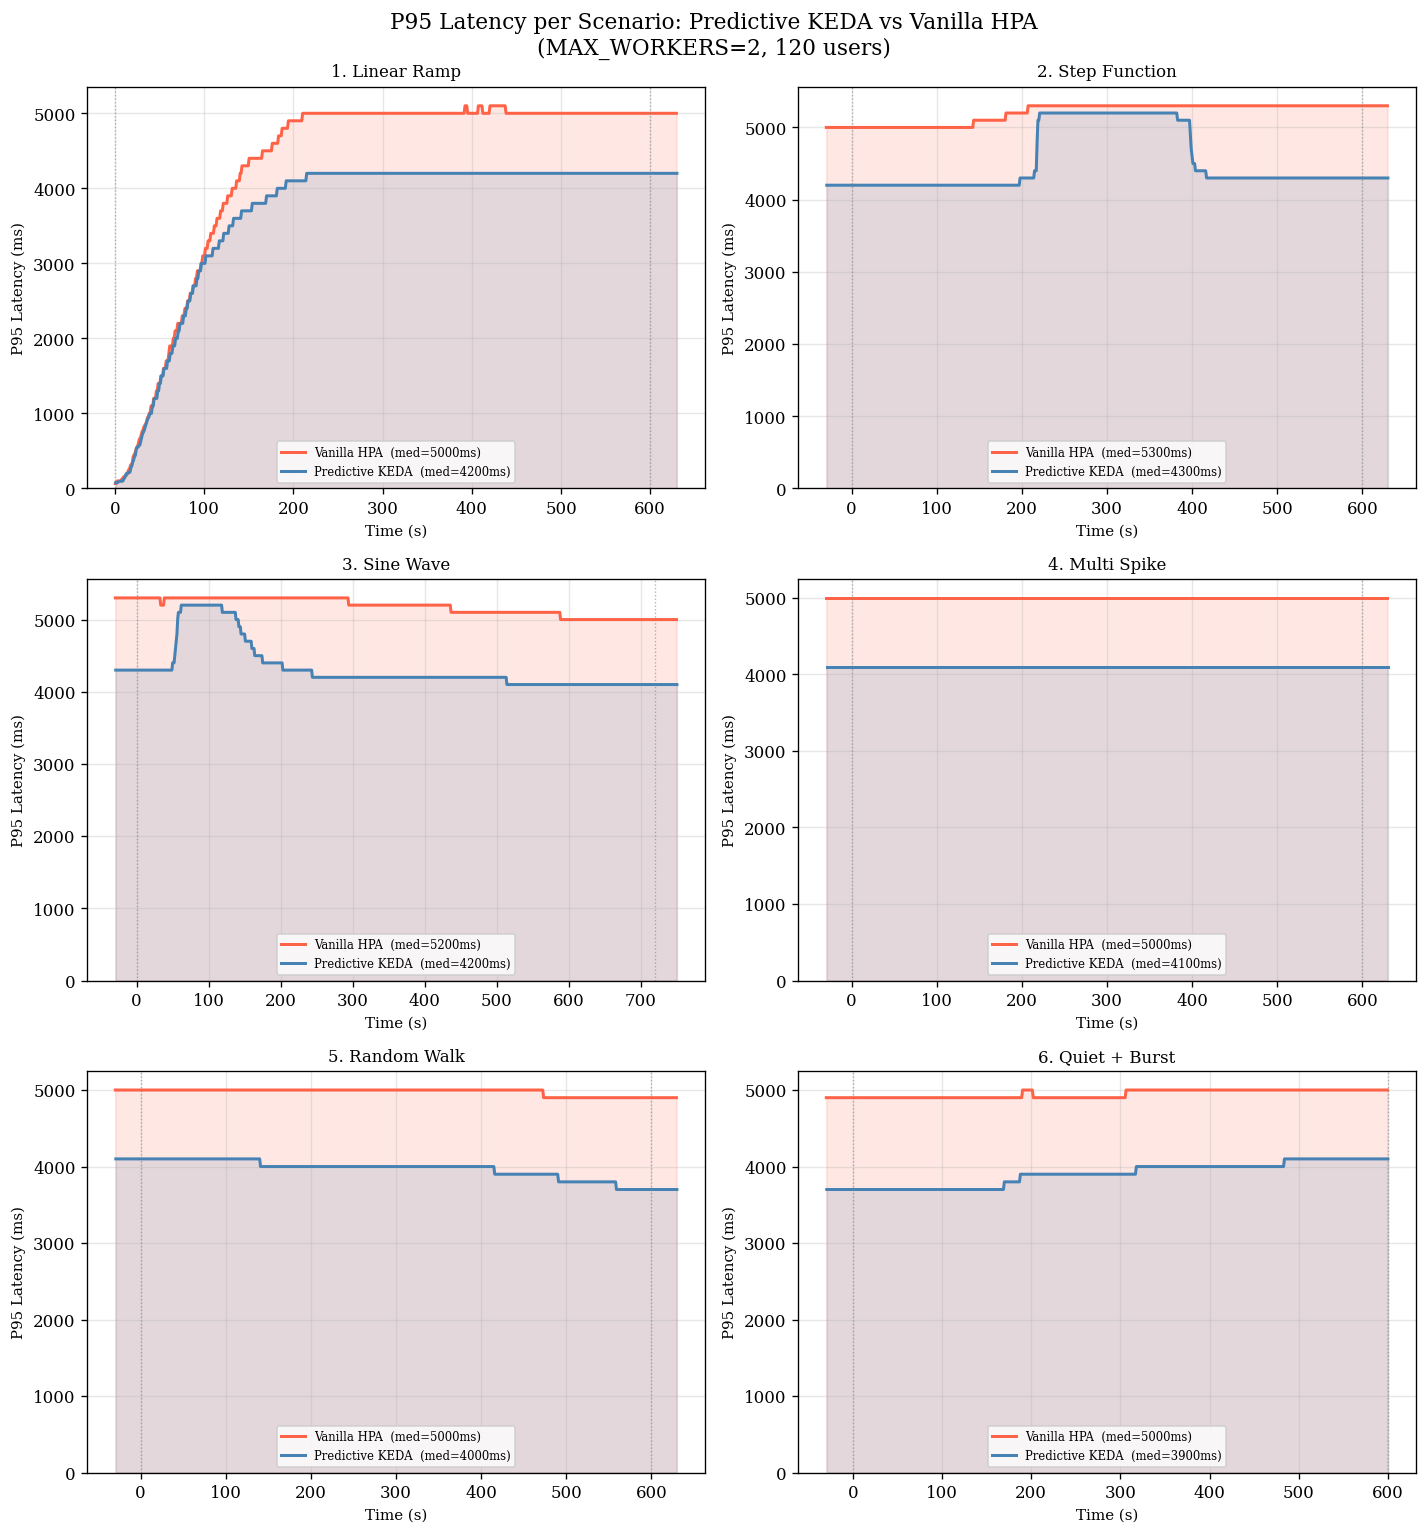

Saved: notebooks/mw2_latency_p95.png


In [76]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.flatten()

for i, name in enumerate(SCENARIO_NAMES):
    ax = axes[i]
    full_h, act_h = slice_scenario(hist_hpa_raw,  name, ROUND_HPA)
    full_k, act_k = slice_scenario(hist_keda_raw, name, ROUND_KEDA)

    for full, act, color, label in [
        (full_h, act_h, COLOR_HPA,  LABEL_HPA),
        (full_k, act_k, COLOR_KEDA, LABEL_KEDA),
    ]:
        if not act.empty and act['95%'].notna().any():
            med = int(act['95%'].median())
            ax.fill_between(full['t'], full['95%'], alpha=0.15, color=color)
            ax.plot(full['t'], full['95%'], color=color, linewidth=1.8,
                    label=f'{label}  (med={med}ms)')

    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ts_info = timestamps[ROUND_HPA][name]
    ax.axvline(ts_info['end_unix'] - ts_info['start_unix'],
               color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('P95 Latency (ms)')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)

fig.suptitle('P95 Latency per Scenario: Predictive KEDA vs Vanilla HPA\n'
             '(MAX_WORKERS=2, 120 users)', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/mw2_latency_p95.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/mw2_latency_p95.png')

### Figure 2 — Latency Distribution (Aggregate Box Plot)

/tmp/ipykernel_149796/859657626.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Vanilla\nHPA', 'Predictive\nKEDA'],
/tmp/ipykernel_149796/859657626.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Vanilla\nHPA', 'Predictive\nKEDA'],
/tmp/ipykernel_149796/859657626.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Vanilla\nHPA', 'Predictive\nKEDA'],


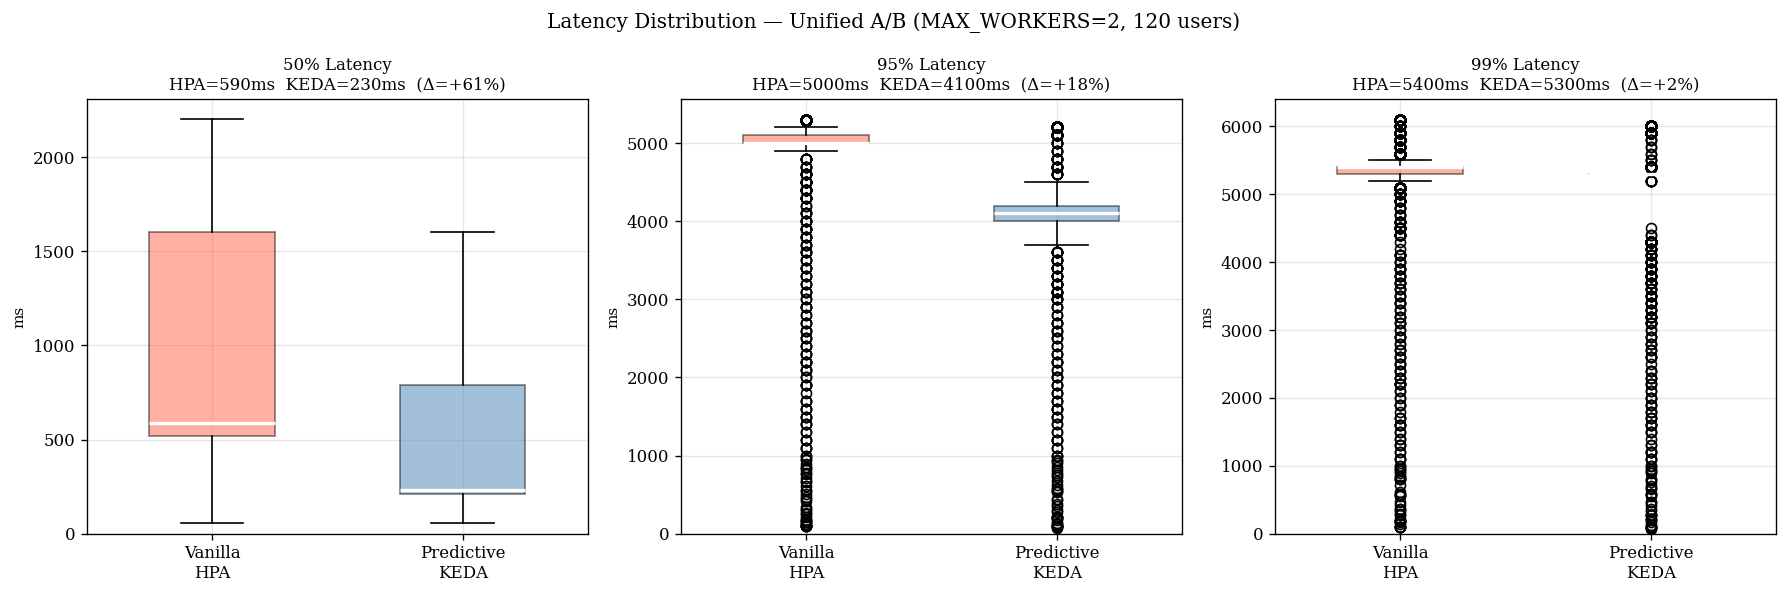


Metric                        HPA         KEDA      Δ (abs)      Δ (%)
----------------------------------------------------------------------
  50% median                590ms        230ms       -360ms    -61.0%
  95% median               5000ms       4100ms       -900ms    -18.0%
  99% median               5400ms       5300ms       -100ms     -1.9%


In [77]:
rh_active = hist_hpa[hist_hpa['Requests/s'] > 0.5]
rk_active = hist_keda[hist_keda['Requests/s'] > 0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pct in zip(axes, ['50%', '95%', '99%']):
    data = [rh_active[pct].dropna().values, rk_active[pct].dropna().values]
    bp = ax.boxplot(data, labels=['Vanilla\nHPA', 'Predictive\nKEDA'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor(COLOR_HPA);  bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor(COLOR_KEDA); bp['boxes'][1].set_alpha(0.5)
    for med in bp['medians']:
        med.set_color('white'); med.set_linewidth(2)
    h_med = rh_active[pct].median()
    k_med = rk_active[pct].median()
    diff_pct = (h_med - k_med) / h_med * 100 if h_med else 0
    ax.set_title(f'{pct} Latency\nHPA={h_med:.0f}ms  KEDA={k_med:.0f}ms  (Δ={diff_pct:+.0f}%)')
    ax.set_ylabel('ms')
    ax.set_ylim(bottom=0)

fig.suptitle('Latency Distribution — Unified A/B (MAX_WORKERS=2, 120 users)', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/mw2_latency_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"Metric":<20} {"HPA":>12} {"KEDA":>12} {"Δ (abs)":>12} {"Δ (%)": >10}')
print('-' * 70)
for pct in ['50%', '95%', '99%']:
    h = rh_active[pct].median()
    k = rk_active[pct].median()
    print(f'  {pct} median{"":<8} {h:>10.0f}ms {k:>10.0f}ms '
          f'{k-h:>+10.0f}ms {(k-h)/h*100:>+8.1f}%')

### Figure 3 — RPS per Scenario (load shape verification)

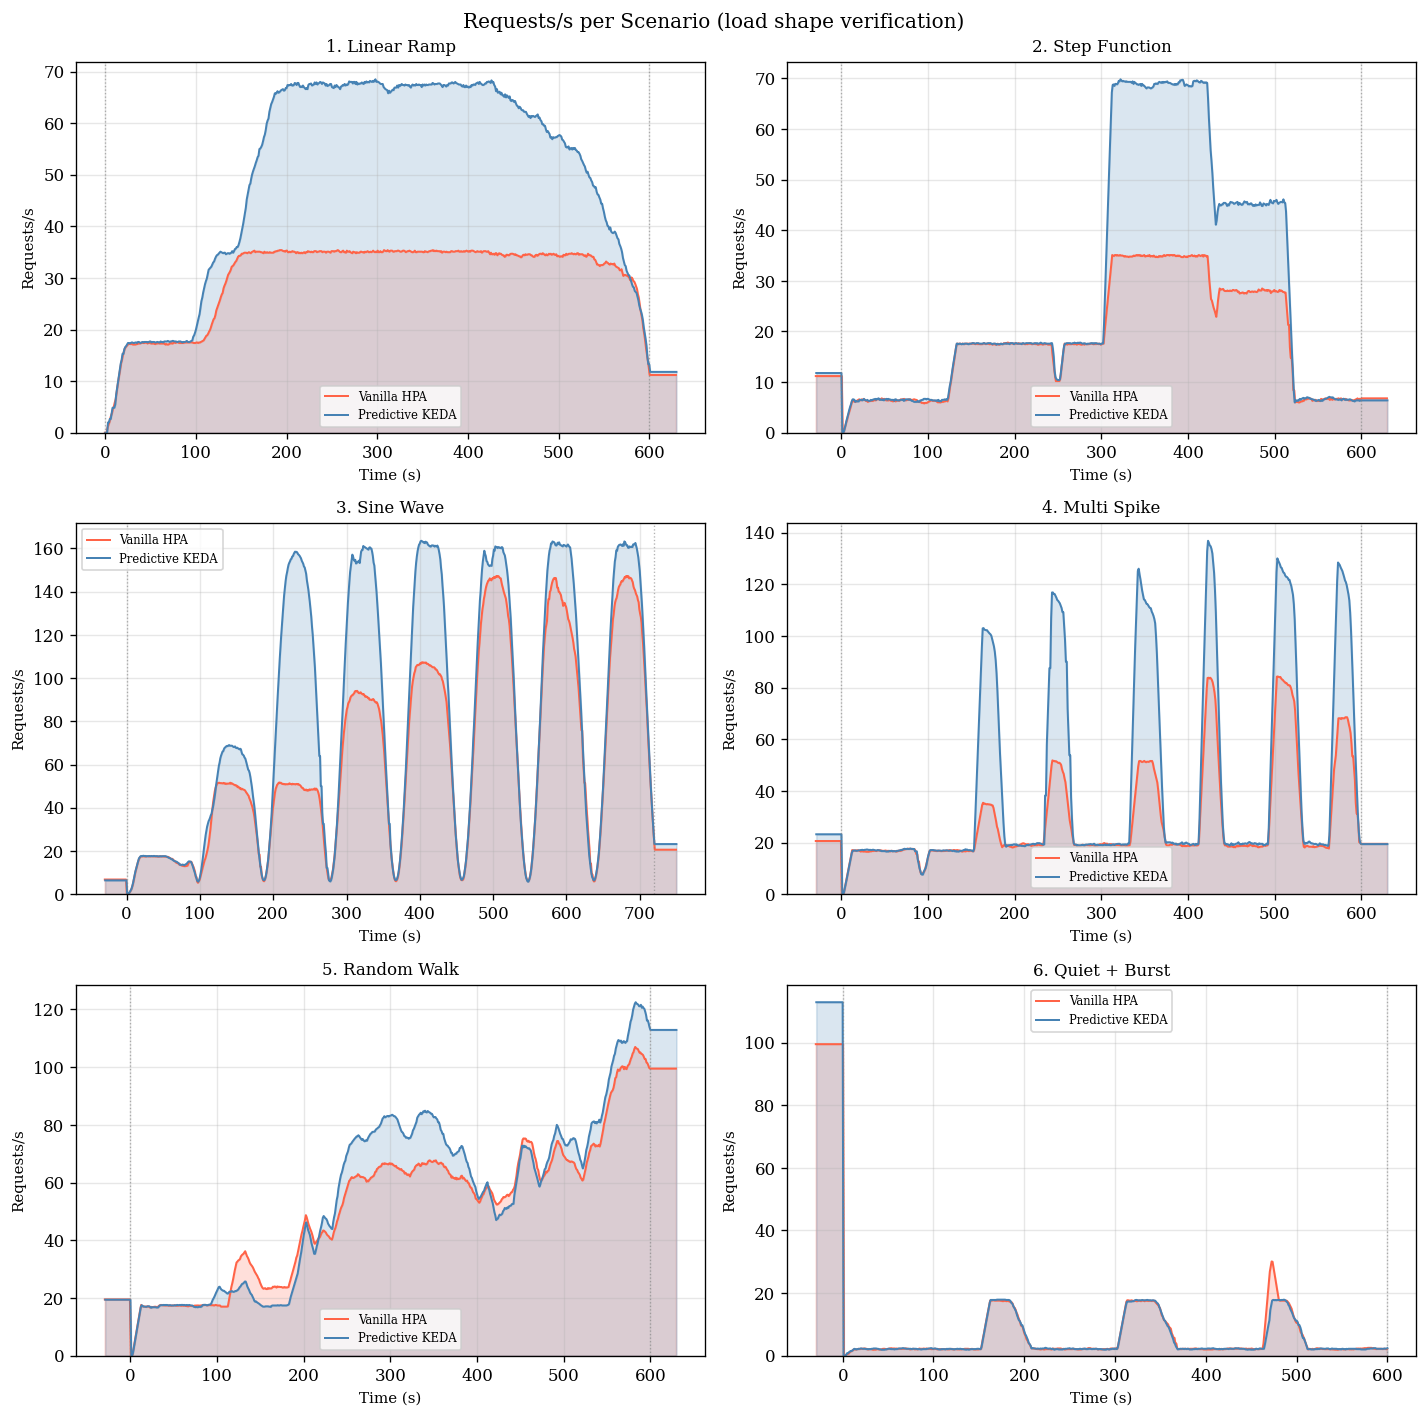

Saved: notebooks/mw2_rps.png


In [78]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, name in enumerate(SCENARIO_NAMES):
    ax = axes[i]
    s_h, _ = slice_scenario(hist_hpa_raw,  name, ROUND_HPA,  min_rps=0.0)
    s_k, _ = slice_scenario(hist_keda_raw, name, ROUND_KEDA, min_rps=0.0)

    ax.fill_between(s_h['t'], s_h['Requests/s'], alpha=0.2, color=COLOR_HPA)
    ax.plot(s_h['t'], s_h['Requests/s'], color=COLOR_HPA,  linewidth=1.2, label=LABEL_HPA)
    ax.fill_between(s_k['t'], s_k['Requests/s'], alpha=0.2, color=COLOR_KEDA)
    ax.plot(s_k['t'], s_k['Requests/s'], color=COLOR_KEDA, linewidth=1.2, label=LABEL_KEDA)

    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ts_info = timestamps[ROUND_HPA][name]
    ax.axvline(ts_info['end_unix'] - ts_info['start_unix'],
               color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Requests/s')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)

fig.suptitle('Requests/s per Scenario (load shape verification)', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/mw2_rps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/mw2_rps.png')

---
## 2 — Prometheus: Replicas, CPU, GRU Prediction

In [79]:
CPU_UTIL_Q = (
    'sum(rate(container_cpu_usage_seconds_total'
    '{pod=~"cpu-service-.*",container!="POD"}[30s]))'
    '/sum(kube_pod_container_resource_limits'
    '{pod=~"cpu-service-.*",resource="cpu",container!="POD"})'
)

def prom_range(query: str, start: float, end: float, step: str = '15s') -> pd.DataFrame:
    r = requests.get(PROM,
                     params={'query': query, 'start': start, 'end': end, 'step': step},
                     timeout=10)
    result = r.json()['data']['result']
    if not result:
        return pd.DataFrame(columns=['ts', 'value'])
    values = result[0]['values']
    df = pd.DataFrame(values, columns=['ts', 'value'])
    df['ts']    = df['ts'].astype(float)
    df['value'] = pd.to_numeric(df['value'])
    return df

def add_sec(df: pd.DataFrame, start: float) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    df['sec'] = df['ts'] - start
    return df

def fetch_scenario(round_key: str, scenario: str) -> dict:
    ts_info = timestamps[round_key][scenario]
    start, end = ts_info['start_unix'], ts_info['end_unix']
    replicas = add_sec(
        prom_range('kube_deployment_status_replicas_ready{deployment="cpu-service"}',
                   start, end), start)
    cpu  = add_sec(prom_range(CPU_UTIL_Q, start, end), start)
    pred = add_sec(prom_range('gru_predicted_cpu_util', start, end), start)
    return {'replicas': replicas, 'cpu': cpu, 'pred': pred}

# Connectivity check
try:
    ts0 = timestamps[ROUND_HPA][SCENARIO_NAMES[0]]
    test = prom_range(
        'kube_deployment_status_replicas_ready{deployment="cpu-service"}',
        ts0['start_unix'], ts0['end_unix'])
    print(f'Prometheus OK — {len(test)} points for {SCENARIO_NAMES[0]} ({ROUND_HPA})')
except Exception as e:
    print(f'Prometheus error: {e}')

Prometheus OK — 41 points for 1. Linear Ramp (round_a_mw2_3)


### Figure 4 — CPU Load (millicores) + Replica Count per Scenario (6×2 grid)

Left column = Vanilla HPA. Right column = Predictive KEDA.  
Shaded area = total CPU consumed across all pods (millicores). Black step = replica count (right axis).  
Axes are aligned: 1 replica on the right axis = 1000m on the left axis.  
Orange dashed = GRU prediction in millicores (KEDA only). Red dotted = KEDA threshold (50% × replicas × 1000m).

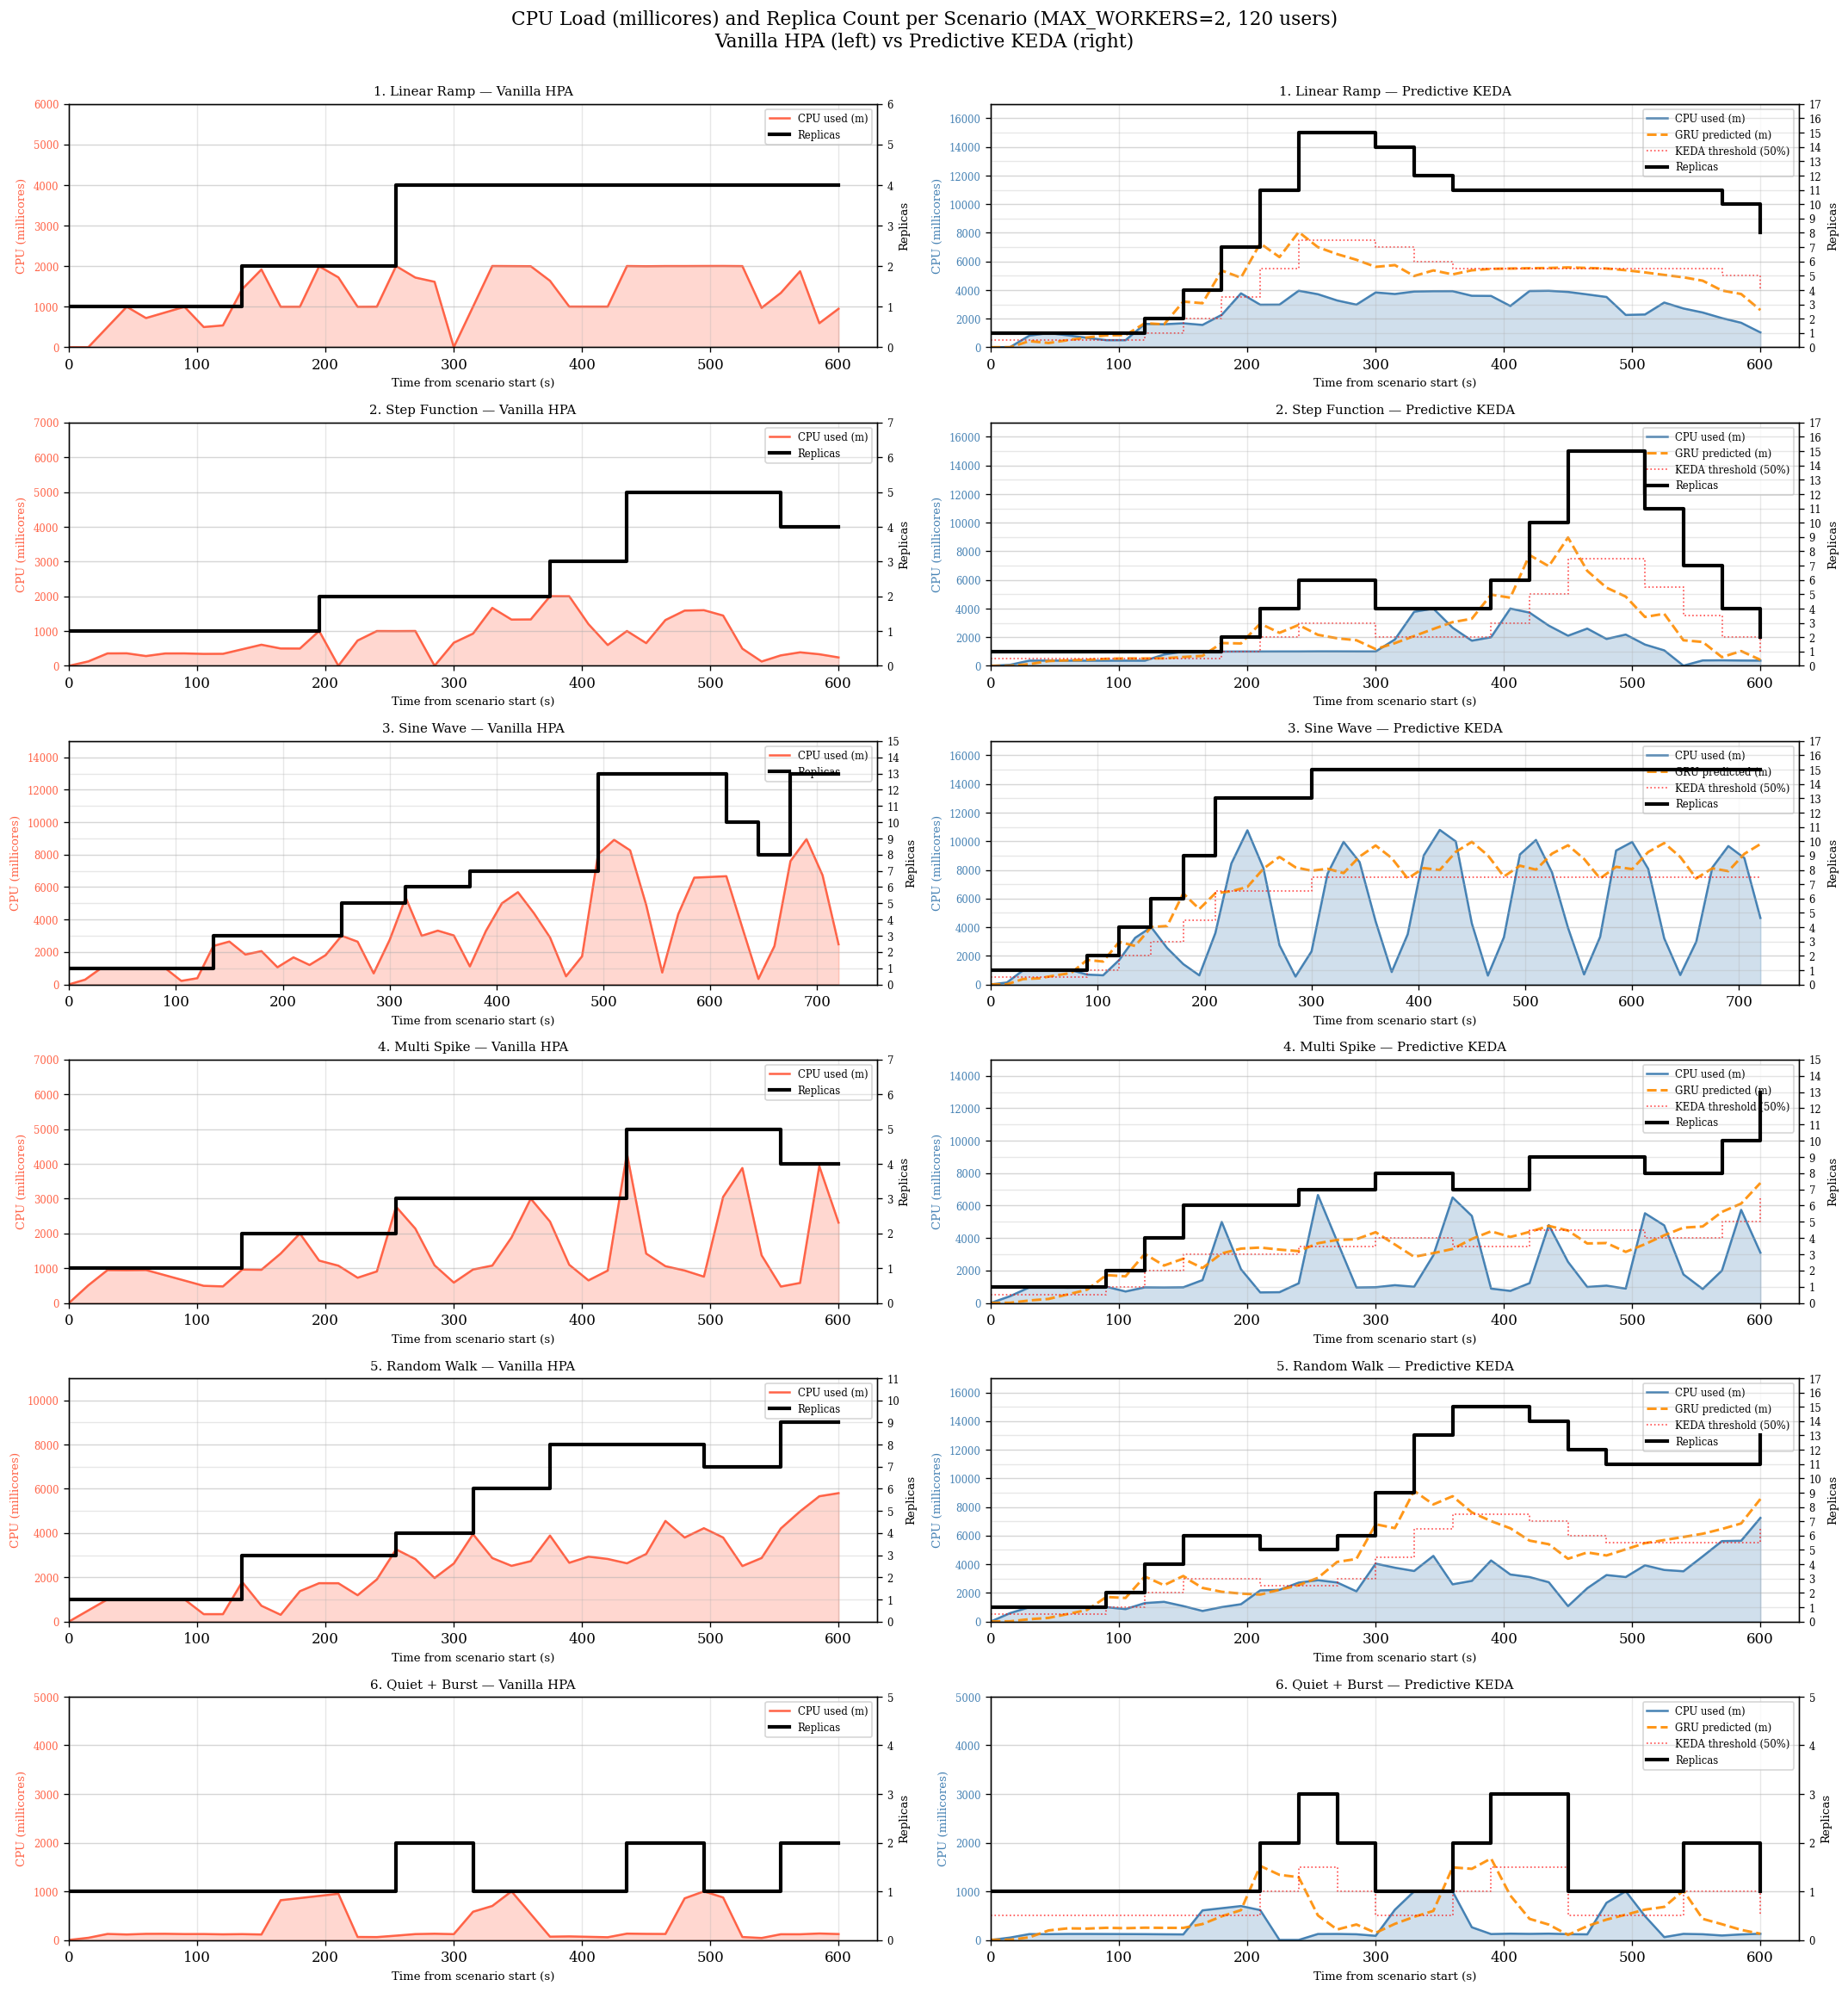

Saved: notebooks/mw2_replica_cpu_scenarios.png


In [80]:
ROUNDS = [
    (ROUND_HPA,  LABEL_HPA,  COLOR_HPA),
    (ROUND_KEDA, LABEL_KEDA, COLOR_KEDA),
]

CPU_LIMIT_M = 1000  # millicores per pod

def _step_interp(rep_df: pd.DataFrame, sec_arr) -> np.ndarray:
    """Step-interpolate replica count onto sec_arr grid."""
    out = []
    for s in sec_arr:
        prev = rep_df[rep_df['sec'] <= s]
        out.append(float(prev['value'].iloc[-1]) if not prev.empty
                   else float(rep_df['value'].iloc[0]))
    return np.array(out)

fig, axes = plt.subplots(len(SCENARIO_NAMES), 2,
                         figsize=(18, len(SCENARIO_NAMES) * 3.2))
fig.suptitle('CPU Load (millicores) and Replica Count per Scenario (MAX_WORKERS=2, 120 users)\n'
             'Vanilla HPA (left) vs Predictive KEDA (right)',
             fontsize=13, y=1.002)

for row, scenario in enumerate(SCENARIO_NAMES):
    for col, (round_key, label, color) in enumerate(ROUNDS):
        ax = axes[row][col]
        data = fetch_scenario(round_key, scenario)

        # Determine y-axis limits (aligned: 1 replica = 1000m)
        max_r = int(data['replicas']['value'].max()) if not data['replicas'].empty else 5
        y_lim_r = max(max_r + 2, 5)

        # Total CPU consumed in millicores = util * replicas * 1000m
        if not data['cpu'].empty and not data['replicas'].empty:
            sec_arr   = data['cpu']['sec'].values
            rep_interp = _step_interp(data['replicas'], sec_arr)
            cpu_m      = data['cpu']['value'].values * rep_interp * CPU_LIMIT_M
            ax.fill_between(sec_arr, cpu_m, alpha=0.25, color=color)
            ax.plot(sec_arr, cpu_m, color=color, linewidth=1.5, label='CPU used (m)')

        if round_key == ROUND_KEDA:
            # GRU prediction in millicores
            if not data['pred'].empty and not data['replicas'].empty:
                pred_sec   = data['pred']['sec'].values
                rep_pred   = _step_interp(data['replicas'], pred_sec)
                pred_m     = data['pred']['value'].values * rep_pred * CPU_LIMIT_M
                ax.plot(pred_sec, pred_m, color=COLOR_PRED, linewidth=1.8,
                        linestyle='--', alpha=0.9, label='GRU predicted (m)')
            # Dynamic threshold: 50% × replicas × 1000m
            if not data['replicas'].empty:
                ax.step(data['replicas']['sec'],
                        data['replicas']['value'] * CPU_LIMIT_M * 0.5,
                        color='red', linewidth=1.0, linestyle=':', where='post',
                        alpha=0.7, label='KEDA threshold (50%)')

        ax.set_ylabel('CPU (millicores)', color=color, fontsize=8)
        ax.tick_params(axis='y', labelcolor=color, labelsize=7)
        ax.set_ylim(0, y_lim_r * CPU_LIMIT_M)  # aligned with replica axis

        # Right axis: replica count — 1 replica visually = 1000m on left axis
        ax2 = ax.twinx()
        if not data['replicas'].empty:
            ax2.step(data['replicas']['sec'], data['replicas']['value'],
                     color='black', linewidth=2.5, where='post', label='Replicas')
            ax2.yaxis.set_major_locator(mticker.MultipleLocator(1))
        ax2.set_ylim(0, y_lim_r)
        ax2.set_ylabel('Replicas', fontsize=8)
        ax2.tick_params(labelsize=7)

        lines1, labs1 = ax.get_legend_handles_labels()
        lines2, labs2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labs1 + labs2, fontsize=7, loc='upper right')
        ax.set_title(f'{scenario} — {label}', fontsize=9)
        ax.set_xlabel('Time from scenario start (s)', fontsize=8)
        ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig('../notebooks/mw2_replica_cpu_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/mw2_replica_cpu_scenarios.png')

### Table 2 — Per-Pod CPU Utilisation: Vanilla HPA vs Predictive KEDA

Per-pod average utilisation `[0, 1]`. `>50%` = fraction of time CPU exceeded KEDA scale-up threshold.

In [81]:
rows = []
for name in SCENARIO_NAMES:
    vals = {}
    for round_key in (ROUND_HPA, ROUND_KEDA):
        ts_info = timestamps[round_key][name]
        start, end = ts_info['start_unix'], ts_info['end_unix']
        df = prom_range(CPU_UTIL_Q, start, end)
        vals[round_key] = df['value'].values if not df.empty else np.array([np.nan])

    h, k = vals[ROUND_HPA], vals[ROUND_KEDA]
    rows.append({
        'Scenario':   name,
        'HPA Mean':   round(np.nanmean(h), 3),
        'HPA Max':    round(np.nanmax(h),  3),
        'HPA >50%':   f'{(h > 0.5).mean()*100:.1f}%',
        'KEDA Mean':  round(np.nanmean(k), 3),
        'KEDA Max':   round(np.nanmax(k),  3),
        'KEDA >50%':  f'{(k > 0.5).mean()*100:.1f}%',
        'Δ Mean':     f'{np.nanmean(k)-np.nanmean(h):+.3f}',
    })

cpu_df = pd.DataFrame(rows).set_index('Scenario')

print('=== Per-Pod CPU Utilisation [0-1]: Vanilla HPA vs Predictive KEDA ===\n')
print(f'{"Scenario":<22}  {"── HPA ──":^30}  {"── KEDA ──":^30}  {"Δ Mean":>8}')
print(f'{"":22}  {"Mean":>6} {"Max":>6} {">50%":>8}  {"Mean":>6} {"Max":>6} {">50%":>8}  {"":>8}')
print('-' * 95)
for name, r in cpu_df.iterrows():
    print(f'{name:<22}  {r["HPA Mean"]:>6.3f} {r["HPA Max"]:>6.3f} {r["HPA >50%"]:>8}  '
          f'{r["KEDA Mean"]:>6.3f} {r["KEDA Max"]:>6.3f} {r["KEDA >50%"]:>8}  {r["Δ Mean"]:>8}')

# Total saturation time
print()
h_sat_frac = np.array([float(r['HPA >50%'].rstrip('%')) for r in rows])
k_sat_frac = np.array([float(r['KEDA >50%'].rstrip('%')) for r in rows])
print(f'HPA  overall mean >50% fraction: {h_sat_frac.mean():.1f}%')
print(f'KEDA overall mean >50% fraction: {k_sat_frac.mean():.1f}%')

cpu_df

=== Per-Pod CPU Utilisation [0-1]: Vanilla HPA vs Predictive KEDA ===

Scenario                          ── HPA ──                       ── KEDA ──              Δ Mean
                          Mean    Max     >50%    Mean    Max     >50%          
-----------------------------------------------------------------------------------------------
1. Linear Ramp           0.474  1.000    51.3%   0.345  1.001    15.4%    -0.129
2. Step Function         0.335  0.834    27.5%   0.348  1.001    19.5%    +0.013
3. Sine Wave             0.502  1.001    57.4%   0.443  1.001    49.0%    -0.060
4. Multi Spike           0.520  1.000    46.2%   0.385  0.974    34.1%    -0.136
5. Random Walk           0.536  1.002    47.5%   0.367  1.000    23.1%    -0.169
6. Quiet + Burst         0.233  1.001    18.9%   0.240  1.004    18.4%    +0.007

HPA  overall mean >50% fraction: 41.5%
KEDA overall mean >50% fraction: 26.6%


,HPA Mean,HPA Max,HPA >50%,KEDA Mean,KEDA Max,KEDA >50%,Δ Mean
Scenario,,,,,,,
1. Linear Ramp,0.474,1.000,51.3%,0.345,1.001,15.4%,-0.129
2. Step Function,0.335,0.834,27.5%,0.348,1.001,19.5%,+0.013
3. Sine Wave,0.502,1.001,57.4%,0.443,1.001,49.0%,-0.060
4. Multi Spike,0.520,1.000,46.2%,0.385,0.974,34.1%,-0.136
5. Random Walk,0.536,1.002,47.5%,0.367,1.000,23.1%,-0.169
6. Quiet + Burst,0.233,1.001,18.9%,0.240,1.004,18.4%,+0.007


---
## 3 — Scale-Up Lag

Scale-up lag = seconds from scenario start to first increase in `replicas_ready`.

In [82]:
def measure_scaleup_lag(replicas_df: pd.DataFrame) -> dict:
    if replicas_df.empty:
        return {'init': None, 'max': None, 'lag_s': None}
    init = replicas_df['value'].iloc[0]
    peak = replicas_df['value'].max()
    scale_rows = replicas_df[replicas_df['value'] > init]
    lag = scale_rows['sec'].iloc[0] if not scale_rows.empty else None
    return {'init': int(init), 'max': int(peak),
            'lag_s': round(lag) if lag is not None else None}

lag_rows = []
print(f'{"Scenario":<22}  {"HPA Init":>9} {"HPA Max":>8} {"HPA Lag":>10}  ||  '
      f'{"KEDA Init":>9} {"KEDA Max":>8} {"KEDA Lag":>10}')
print('-' * 95)

for name in SCENARIO_NAMES:
    dh = fetch_scenario(ROUND_HPA,  name)
    dk = fetch_scenario(ROUND_KEDA, name)
    mh = measure_scaleup_lag(dh['replicas'])
    mk = measure_scaleup_lag(dk['replicas'])

    lag_h = f'{mh["lag_s"]} s' if mh['lag_s'] is not None else 'pre-warmed'
    lag_k = f'{mk["lag_s"]} s' if mk['lag_s'] is not None else 'pre-warmed'

    print(f'{name:<22}  {str(mh["init"]):>9} {str(mh["max"]):>8} {lag_h:>10}  ||  '
          f'{str(mk["init"]):>9} {str(mk["max"]):>8} {lag_k:>10}')
    lag_rows.append({'Scenario': name,
                     'HPA_init': mh['init'], 'HPA_max': mh['max'], 'HPA_lag': lag_h,
                     'KEDA_init': mk['init'], 'KEDA_max': mk['max'], 'KEDA_lag': lag_k})

lag_df = pd.DataFrame(lag_rows)

Scenario                 HPA Init  HPA Max    HPA Lag  ||  KEDA Init KEDA Max   KEDA Lag
-----------------------------------------------------------------------------------------------
1. Linear Ramp                  1        4      135 s  ||          1       15      120 s
2. Step Function                1        5      195 s  ||          1       15      180 s
3. Sine Wave                    1       13      135 s  ||          1       15       90 s
4. Multi Spike                  1        5      135 s  ||          1       13       90 s
5. Random Walk                  1        9      135 s  ||          1       15       90 s
6. Quiet + Burst                1        2      255 s  ||          1        3      210 s


### Figure 5 — Scale-Up Timeline: All 6 Scenarios (2×3 grid)

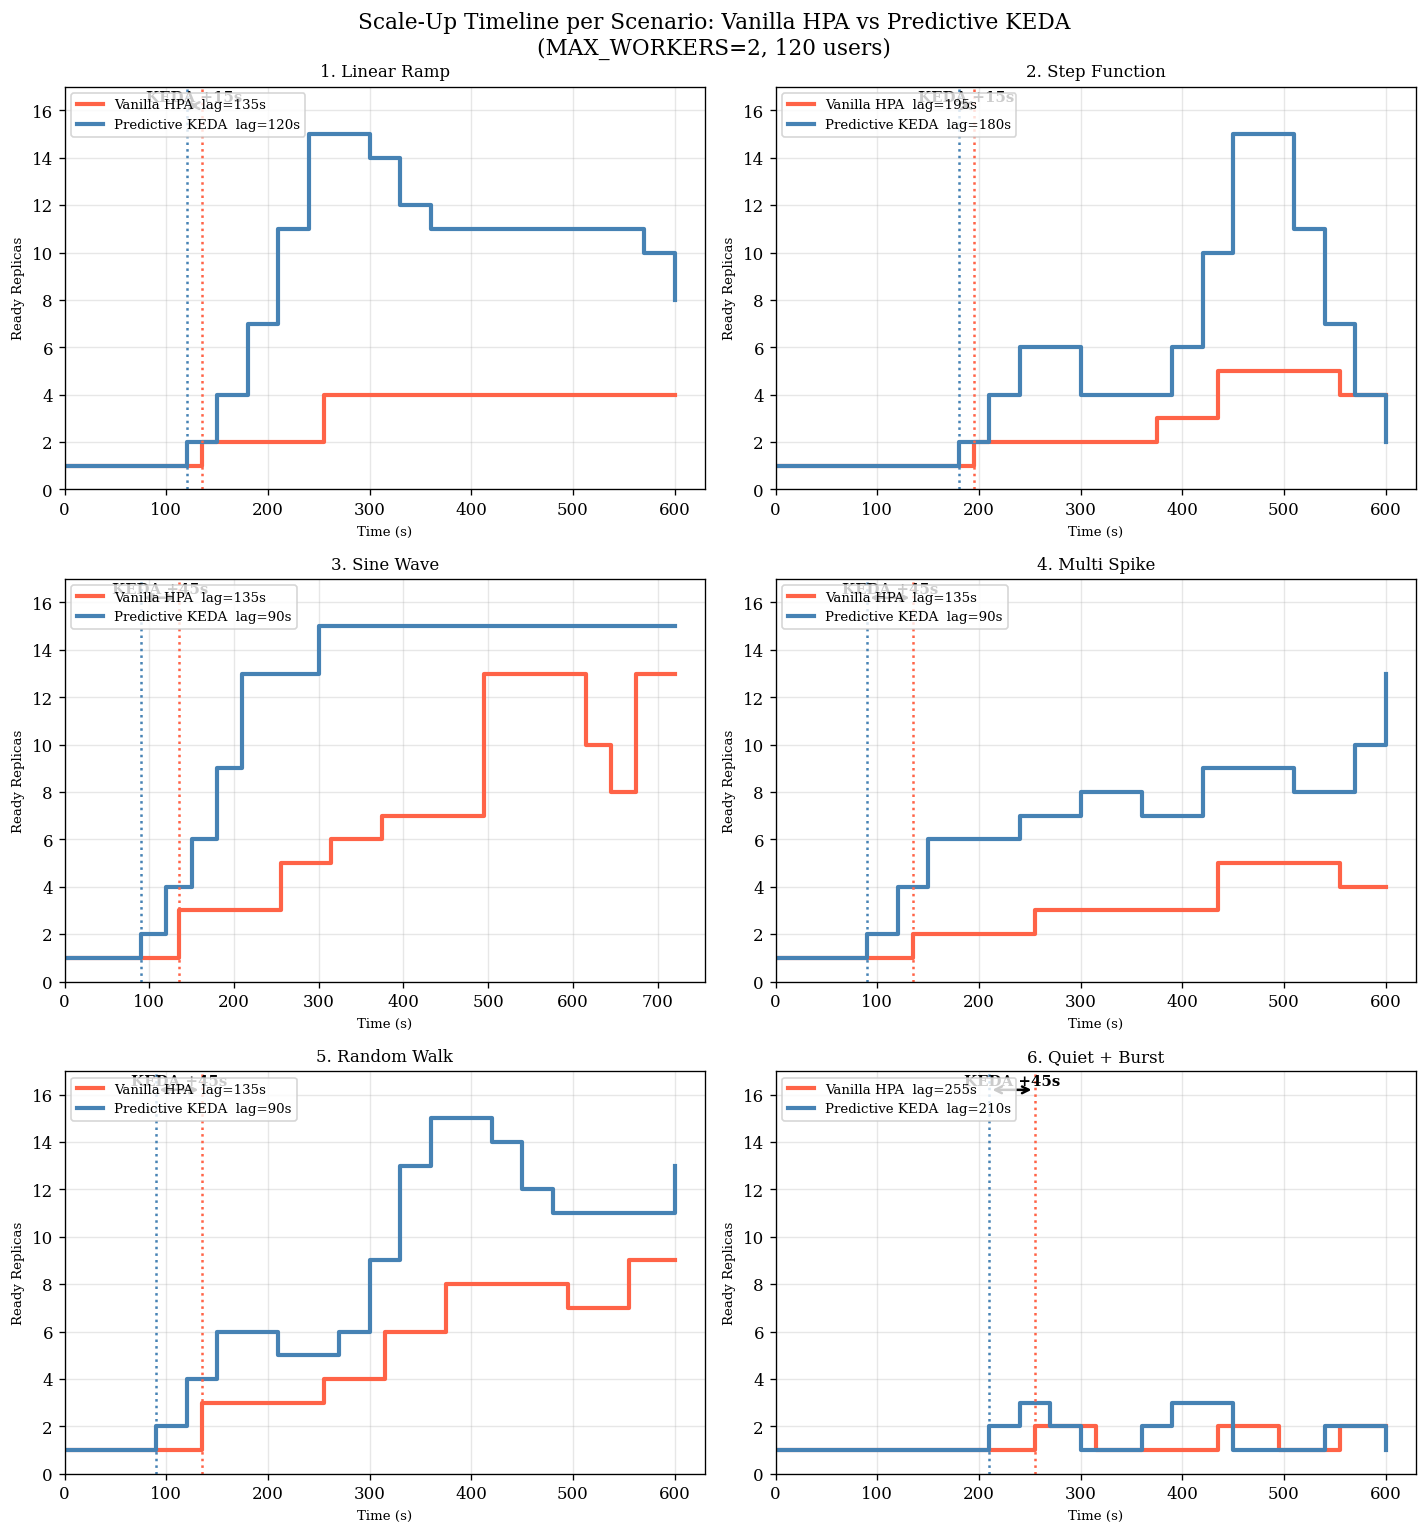

Saved: notebooks/mw2_scaleup_lag.png


In [83]:
global_ymax = 1
for name in SCENARIO_NAMES:
    for rk in (ROUND_HPA, ROUND_KEDA):
        d = fetch_scenario(rk, name)
        if not d['replicas'].empty:
            global_ymax = max(global_ymax, d['replicas']['value'].max())
global_ymax = int(global_ymax) + 2

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.flatten()

for i, name in enumerate(SCENARIO_NAMES):
    ax = axes[i]
    dh = fetch_scenario(ROUND_HPA,  name)
    dk = fetch_scenario(ROUND_KEDA, name)
    mh = measure_scaleup_lag(dh['replicas'])
    mk = measure_scaleup_lag(dk['replicas'])

    lbl_h = (f'{LABEL_HPA}  lag={mh["lag_s"]}s'  if mh['lag_s'] else f'{LABEL_HPA} (pre-warmed)')
    lbl_k = (f'{LABEL_KEDA}  lag={mk["lag_s"]}s' if mk['lag_s'] else f'{LABEL_KEDA} (pre-warmed)')

    if not dh['replicas'].empty:
        ax.step(dh['replicas']['sec'], dh['replicas']['value'],
                where='post', color=COLOR_HPA, linewidth=2.5, label=lbl_h)
    if not dk['replicas'].empty:
        ax.step(dk['replicas']['sec'], dk['replicas']['value'],
                where='post', color=COLOR_KEDA, linewidth=2.5, label=lbl_k)

    y_ann = global_ymax - 0.8

    if mh['lag_s'] and mk['lag_s']:
        ax.axvline(mh['lag_s'], ls=':', color=COLOR_HPA,  lw=1.5)
        ax.axvline(mk['lag_s'], ls=':', color=COLOR_KEDA, lw=1.5)
        diff = mh['lag_s'] - mk['lag_s']
        if diff != 0:
            mid = (mh['lag_s'] + mk['lag_s']) / 2
            ax.annotate('', xy=(min(mh['lag_s'], mk['lag_s']), y_ann),
                        xytext=(max(mh['lag_s'], mk['lag_s']), y_ann),
                        arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
            adv = f'KEDA +{diff}s' if diff > 0 else f'HPA +{-diff}s'
            ax.text(mid, y_ann + 0.2, adv, ha='center', fontsize=9, fontweight='bold')
        else:
            ax.text(mh['lag_s'], y_ann, 'Tied', ha='center', fontsize=8, fontstyle='italic')
    elif mh['lag_s'] and not mk['lag_s']:
        ax.axvline(mh['lag_s'], ls=':', color=COLOR_HPA, lw=1.5)
        ax.text(0.97, 0.08, 'KEDA: pre-warmed', transform=ax.transAxes,
                ha='right', fontsize=8, color=COLOR_KEDA, style='italic')
    elif mk['lag_s'] and not mh['lag_s']:
        ax.axvline(mk['lag_s'], ls=':', color=COLOR_KEDA, lw=1.5)
        ax.text(0.97, 0.08, 'HPA: pre-warmed', transform=ax.transAxes,
                ha='right', fontsize=8, color=COLOR_HPA, style='italic')

    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Ready Replicas', fontsize=8)
    ax.set_xlim(left=0)
    ax.set_ylim(0, global_ymax)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Scale-Up Timeline per Scenario: Vanilla HPA vs Predictive KEDA\n'
             '(MAX_WORKERS=2, 120 users)', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/mw2_scaleup_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/mw2_scaleup_lag.png')

---
## 4 — Advantage Window Analysis

The predictive advantage is concentrated in the window where KEDA holds more replicas than HPA.  
Outside this window, latency should converge (both systems at the same replica count).

Unlike the 2-scenario stress test, here we have 6 scenarios.  
Expected: Sc.6 Quiet+Burst has no window (no pre-burst signal → honest negative result).

In [84]:
def interp_replicas(replicas_df: pd.DataFrame, sec_list: list) -> list:
    """Step-interpolate replica count to an arbitrary time grid."""
    out = []
    for s in sec_list:
        prev = replicas_df[replicas_df['sec'] <= s]
        out.append(float(prev['value'].iloc[-1]) if not prev.empty
                   else float(replicas_df['value'].iloc[0]))
    return out

def find_advantage_window(scenario: str) -> dict:
    """Returns seconds range where KEDA has strictly more replicas than HPA."""
    rh = fetch_scenario(ROUND_HPA,  scenario)['replicas']
    rk = fetch_scenario(ROUND_KEDA, scenario)['replicas']
    if rh.empty or rk.empty:
        return {'start': None, 'end': None, 'duration': 0}

    all_sec = sorted(set(rh['sec']).union(set(rk['sec'])))
    h_vals  = interp_replicas(rh, all_sec)
    k_vals  = interp_replicas(rk, all_sec)
    advantage = [s for s, h, k in zip(all_sec, h_vals, k_vals) if k > h]
    if not advantage:
        return {'start': None, 'end': None, 'duration': 0}
    return {'start': advantage[0], 'end': advantage[-1],
            'duration': advantage[-1] - advantage[0]}

print(f'{"Scenario":<22}  {"Window start":>13}  {"Window end":>11}  {"Duration":>10}')
print('-' * 65)
for name in SCENARIO_NAMES:
    w = find_advantage_window(name)
    if w['start'] is not None:
        print(f'{name:<22}  {w["start"]:>11.0f} s  {w["end"]:>9.0f} s  {w["duration"]:>8.0f} s')
    else:
        print(f'{name:<22}  {"no advantage window":>35}')

Scenario                 Window start   Window end    Duration
-----------------------------------------------------------------
1. Linear Ramp                  120 s        600 s       480 s
2. Step Function                180 s        570 s       390 s
3. Sine Wave                     90 s        720 s       630 s
4. Multi Spike                   90 s        600 s       510 s
5. Random Walk                   90 s        600 s       510 s
6. Quiet + Burst                210 s        540 s       330 s


### Figure 6 — Replica Count + P50 Latency Overlay (2×3 grid)

Both rounds on the same axes. Shows *why* latency differs: KEDA holds more replicas while HPA reacts.  
Dashed lines = P50 latency (right axis). Gold band = advantage window.

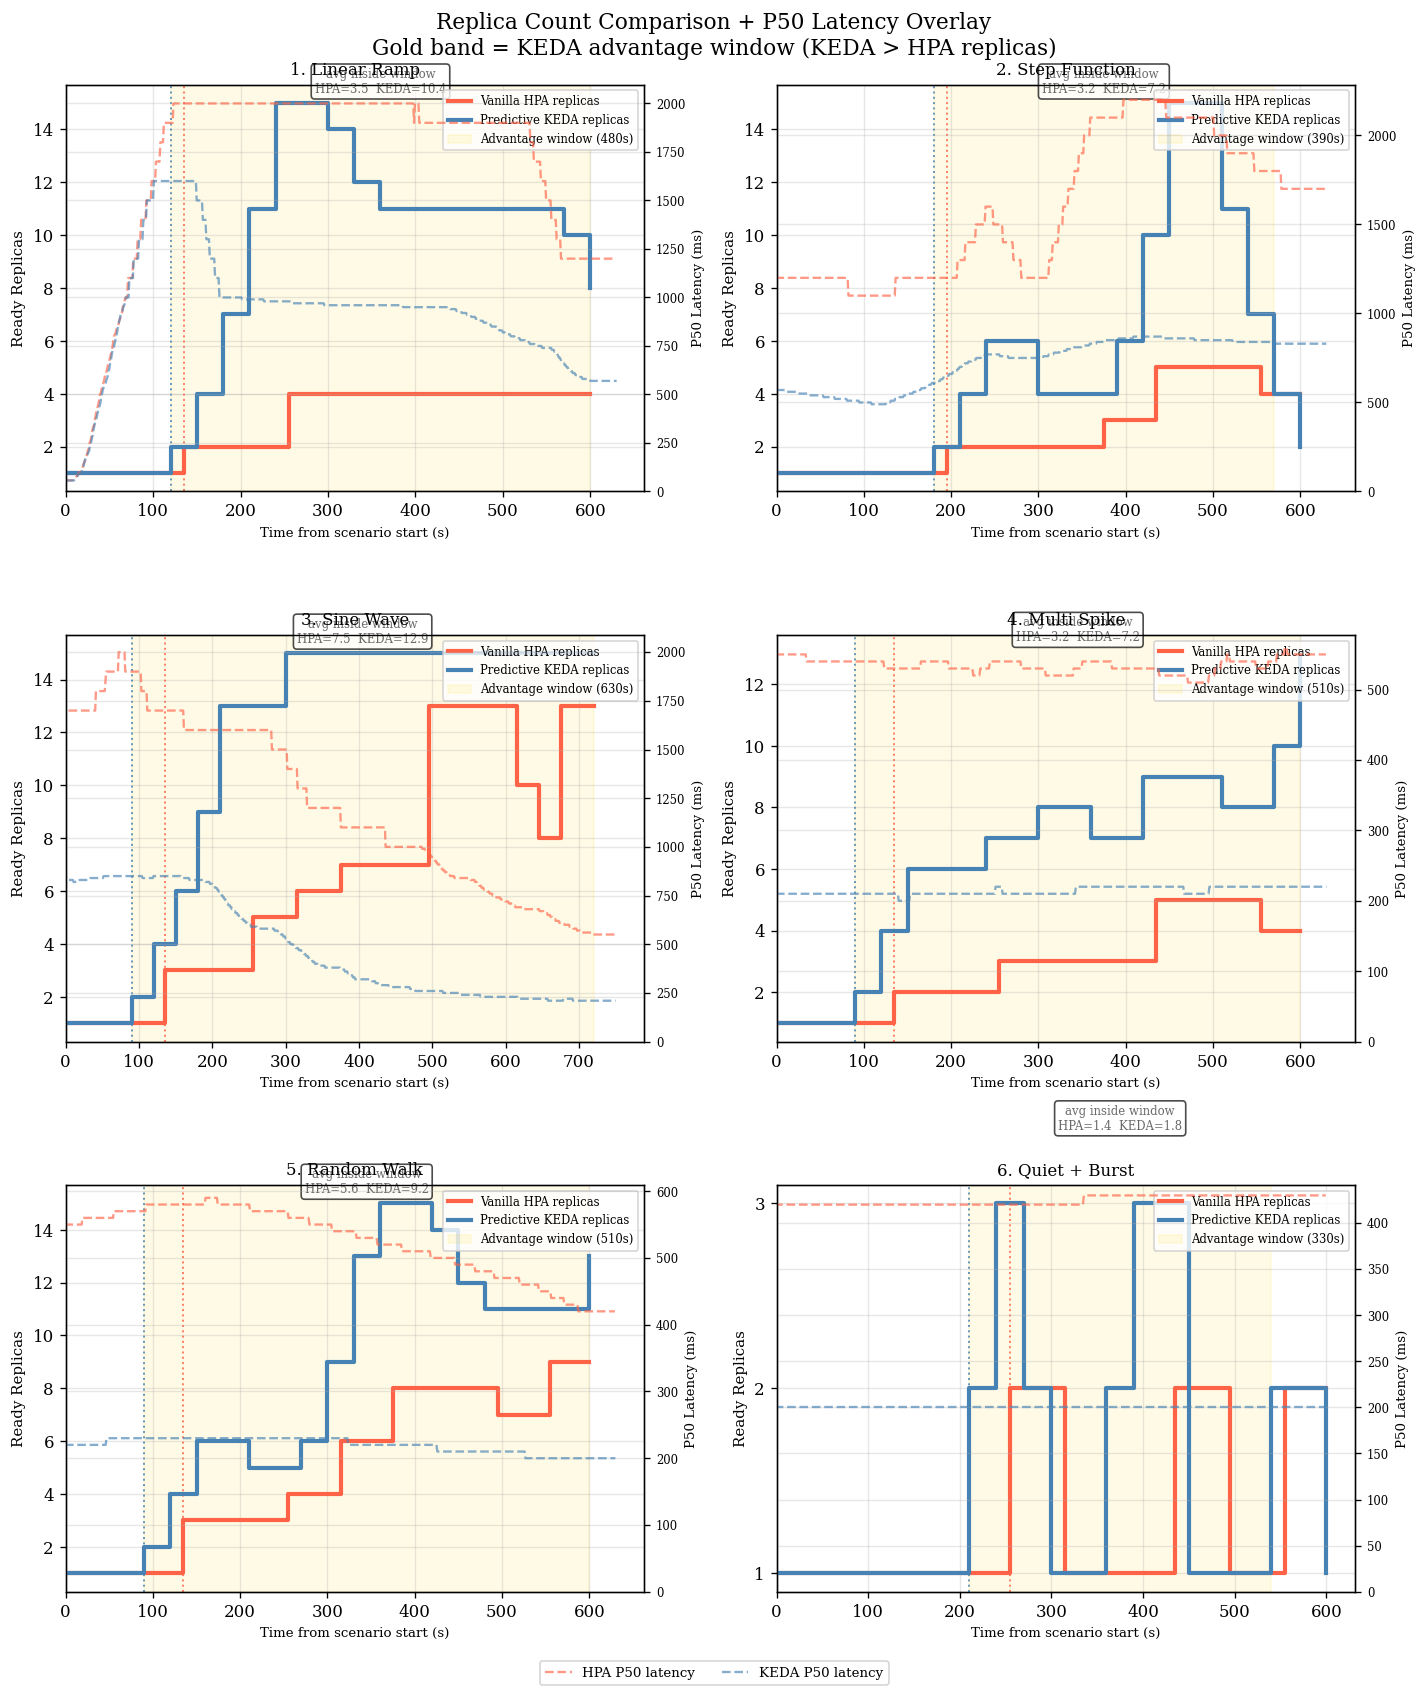

Saved: notebooks/mw2_replica_advantage.png


In [85]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()
fig.suptitle('Replica Count Comparison + P50 Latency Overlay\n'
             'Gold band = KEDA advantage window (KEDA > HPA replicas)', fontsize=13)

for i, name in enumerate(SCENARIO_NAMES):
    ax = axes[i]
    w  = find_advantage_window(name)
    dh = fetch_scenario(ROUND_HPA,  name)
    dk = fetch_scenario(ROUND_KEDA, name)
    full_h, act_h = slice_scenario(hist_hpa_raw,  name, ROUND_HPA)
    full_k, act_k = slice_scenario(hist_keda_raw, name, ROUND_KEDA)

    if not dh['replicas'].empty:
        ax.step(dh['replicas']['sec'], dh['replicas']['value'],
                where='post', color=COLOR_HPA, linewidth=2.5,
                label=f'{LABEL_HPA} replicas', zorder=3)
    if not dk['replicas'].empty:
        ax.step(dk['replicas']['sec'], dk['replicas']['value'],
                where='post', color=COLOR_KEDA, linewidth=2.5,
                label=f'{LABEL_KEDA} replicas', zorder=3)

    ax.set_ylabel('Ready Replicas')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    if w['start'] is not None:
        ax.axvspan(w['start'], w['end'], alpha=0.10, color='gold',
                   label=f'Advantage window ({w["duration"]:.0f}s)')
        common   = sorted(set(dh['replicas']['sec'].tolist()) | set(dk['replicas']['sec'].tolist()))
        win_secs = [s for s in common if w['start'] <= s <= w['end']]
        if win_secs and not dh['replicas'].empty and not dk['replicas'].empty:
            avg_h = np.mean(interp_replicas(dh['replicas'], win_secs))
            avg_k = np.mean(interp_replicas(dk['replicas'], win_secs))
            y_top = max(dh['replicas']['value'].max(), dk['replicas']['value'].max()) + 0.4
            mid   = (w['start'] + w['end']) / 2
            ax.text(mid, y_top,
                    f'avg inside window\nHPA={avg_h:.1f}  KEDA={avg_k:.1f}',
                    ha='center', fontsize=7, color='dimgray',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    # P50 latency (right axis, dashed) — use full_window so padding is visible
    ax2 = ax.twinx()
    for full, color in [(full_h, COLOR_HPA), (full_k, COLOR_KEDA)]:
        if not full.empty and full['50%'].notna().any():
            ax2.plot(full['t'], full['50%'], color=color, linewidth=1.4,
                     linestyle='--', alpha=0.65)
    ax2.set_ylabel('P50 Latency (ms)', fontsize=8)
    ax2.tick_params(labelsize=7)
    ax2.set_ylim(bottom=0)

    # Scale-up markers
    mh = measure_scaleup_lag(dh['replicas'])
    mk = measure_scaleup_lag(dk['replicas'])
    if mh['lag_s']:
        ax.axvline(mh['lag_s'], color=COLOR_HPA,  ls=':', lw=1.2, alpha=0.8)
    if mk['lag_s']:
        ax.axvline(mk['lag_s'], color=COLOR_KEDA, ls=':', lw=1.2, alpha=0.8)

    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Time from scenario start (s)', fontsize=8)
    ax.set_xlim(left=0)
    lines1, labs1 = ax.get_legend_handles_labels()
    ax.legend(lines1, labs1, fontsize=7, loc='upper right')

latency_legend = [
    Line2D([0], [0], color=COLOR_HPA,  lw=1.4, ls='--', alpha=0.65, label='HPA P50 latency'),
    Line2D([0], [0], color=COLOR_KEDA, lw=1.4, ls='--', alpha=0.65, label='KEDA P50 latency'),
]
fig.legend(handles=latency_legend, loc='lower center', ncol=2,
           fontsize=8, framealpha=0.8, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('../notebooks/mw2_replica_advantage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/mw2_replica_advantage.png')

### Table 3 — Latency Inside the Advantage Window: HPA vs KEDA

Same time slice for both autoscalers — isolates the period where replica count differs.

In [86]:
rows = []
for name in SCENARIO_NAMES:
    w = find_advantage_window(name)
    _, act_h = slice_scenario(hist_hpa_raw,  name, ROUND_HPA)
    _, act_k = slice_scenario(hist_keda_raw, name, ROUND_KEDA)

    if w['start'] is None or act_h.empty or act_k.empty:
        rows.append({'Scenario': name, 'Window': 'none',
                     'HPA P50': 'N/A', 'KEDA P50': 'N/A', 'Δ P50': 'N/A',
                     'HPA P95': 'N/A', 'KEDA P95': 'N/A', 'Δ P95': 'N/A'})
        continue

    h_win = act_h[(act_h['t'] >= w['start']) & (act_h['t'] <= w['end'])]
    k_win = act_k[(act_k['t'] >= w['start']) & (act_k['t'] <= w['end'])]

    def med(df, col):
        return int(df[col].median()) if not df.empty and df[col].notna().any() else None

    h50, k50 = med(h_win, '50%'), med(k_win, '50%')
    h95, k95 = med(h_win, '95%'), med(k_win, '95%')

    def delta_str(h, k):
        if h and k:
            return f'{k-h:+d}ms ({(k-h)/h*100:+.0f}%)'
        return 'N/A'

    rows.append({
        'Scenario': name,
        'Window':   f'{w["start"]:.0f}–{w["end"]:.0f}s ({w["duration"]:.0f}s)',
        'HPA P50':  f'{h50}ms' if h50 else 'N/A',
        'KEDA P50': f'{k50}ms' if k50 else 'N/A',
        'Δ P50':    delta_str(h50, k50),
        'HPA P95':  f'{h95}ms' if h95 else 'N/A',
        'KEDA P95': f'{k95}ms' if k95 else 'N/A',
        'Δ P95':    delta_str(h95, k95),
    })

win_df = pd.DataFrame(rows).set_index('Scenario')
print('=== Latency INSIDE Advantage Window (KEDA has more replicas) ===\n')
print(f'{"Scenario":<22}  {"Window":<26}  '
      f'{"HPA P50":>9} {"KEDA P50":>9} {"Δ P50":>18}  '
      f'{"HPA P95":>9} {"KEDA P95":>9} {"Δ P95":>18}')
print('-' * 125)
for name, r in win_df.iterrows():
    print(f'{name:<22}  {str(r["Window"]):<26}  '
          f'{str(r["HPA P50"]):>9} {str(r["KEDA P50"]):>9} {str(r["Δ P50"]):>18}  '
          f'{str(r["HPA P95"]):>9} {str(r["KEDA P95"]):>9} {str(r["Δ P95"]):>18}')

win_df

=== Latency INSIDE Advantage Window (KEDA has more replicas) ===

Scenario                Window                        HPA P50  KEDA P50              Δ P50    HPA P95  KEDA P95              Δ P95
-----------------------------------------------------------------------------------------------------------------------------
1. Linear Ramp          120–600s (480s)                2000ms     960ms     -1040ms (-52%)     5000ms    4200ms      -800ms (-16%)
2. Step Function        180–570s (390s)                1900ms     840ms     -1060ms (-56%)     5300ms    4400ms      -900ms (-17%)
3. Sine Wave            90–720s (630s)                 1100ms     320ms      -780ms (-71%)     5200ms    4200ms     -1000ms (-19%)
4. Multi Spike          90–600s (510s)                  530ms     210ms      -320ms (-60%)     5000ms    4100ms      -900ms (-18%)
5. Random Walk          90–600s (510s)                  530ms     220ms      -310ms (-58%)     5000ms    4000ms     -1000ms (-20%)
6. Quiet + Burst      

,Window,HPA P50,KEDA P50,Δ P50,HPA P95,KEDA P95,Δ P95
Scenario,,,,,,,
1. Linear Ramp,120–600s (480s),2000ms,960ms,-1040ms (-52%),5000ms,4200ms,-800ms (-16%)
2. Step Function,180–570s (390s),1900ms,840ms,-1060ms (-56%),5300ms,4400ms,-900ms (-17%)
3. Sine Wave,90–720s (630s),1100ms,320ms,-780ms (-71%),5200ms,4200ms,-1000ms (-19%)
4. Multi Spike,90–600s (510s),530ms,210ms,-320ms (-60%),5000ms,4100ms,-900ms (-18%)
5. Random Walk,90–600s (510s),530ms,220ms,-310ms (-58%),5000ms,4000ms,-1000ms (-20%)
6. Quiet + Burst,210–540s (330s),430ms,200ms,-230ms (-53%),5000ms,4000ms,-1000ms (-20%)


### Figure 7 — P50 Latency by Phase: Scale-Up / KEDA-Leads / Steady State (2×3 grid)

Isolates *where* the latency advantage occurs across all 6 scenarios.

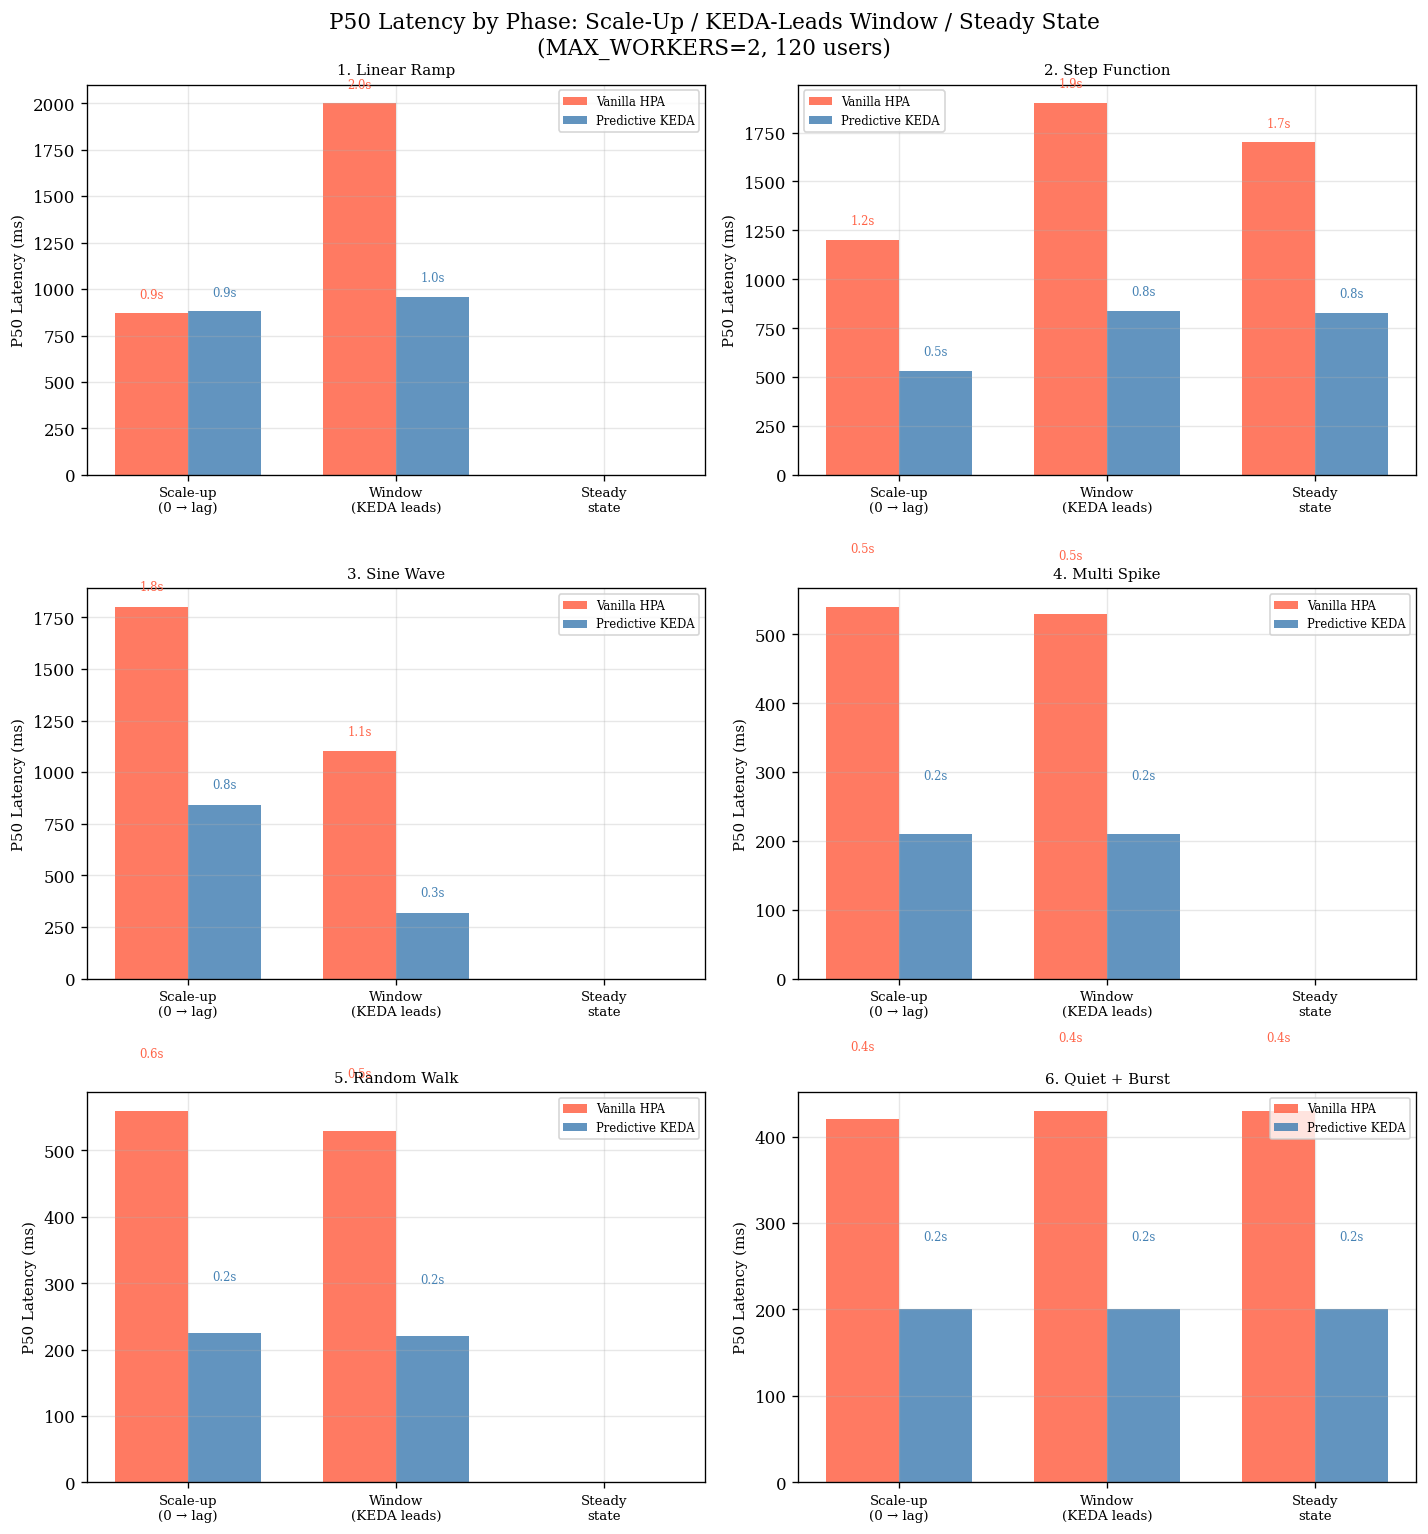

Saved: notebooks/mw2_phase_split_p50.png


In [87]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.flatten()

for i, name in enumerate(SCENARIO_NAMES):
    ax = axes[i]
    w  = find_advantage_window(name)
    dh = fetch_scenario(ROUND_HPA, name)
    mh = measure_scaleup_lag(dh['replicas'])
    _, act_h = slice_scenario(hist_hpa_raw,  name, ROUND_HPA)
    _, act_k = slice_scenario(hist_keda_raw, name, ROUND_KEDA)

    hpa_lag = mh['lag_s'] or 0
    win_s   = w['start'] if w['start'] is not None else hpa_lag
    win_e   = w['end']   if w['end']   is not None else hpa_lag

    phases = [
        ('Scale-up\n(0 → lag)',    0,     win_s),
        ('Window\n(KEDA leads)',   win_s, win_e),
        ('Steady\nstate',          win_e, 9999),
    ]

    h_meds, k_meds = [], []
    for _lbl, ps, pe in phases:
        hs = act_h[(act_h['t'] >= ps) & (act_h['t'] < pe)]
        ks = act_k[(act_k['t'] >= ps) & (act_k['t'] < pe)]
        h_meds.append(hs['50%'].median() if not hs.empty and hs['50%'].notna().any() else 0)
        k_meds.append(ks['50%'].median() if not ks.empty and ks['50%'].notna().any() else 0)

    x_pos = range(len(phases))
    w_bar = 0.35
    bh = ax.bar([xi - w_bar/2 for xi in x_pos], h_meds, w_bar,
                color=COLOR_HPA,  alpha=0.85, label=LABEL_HPA)
    bk = ax.bar([xi + w_bar/2 for xi in x_pos], k_meds, w_bar,
                color=COLOR_KEDA, alpha=0.85, label=LABEL_KEDA)

    for bars, color in [(bh, COLOR_HPA), (bk, COLOR_KEDA)]:
        for b in bars:
            h_val = b.get_height()
            if h_val > 100:
                ax.text(b.get_x() + b.get_width()/2, h_val + 80,
                        f'{h_val/1000:.1f}s', ha='center', fontsize=7, color=color)

    if w['start'] is None:
        ax.text(0.5, 0.92, 'No advantage window', transform=ax.transAxes,
                ha='center', fontsize=8, color='gray', style='italic')

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels([p[0] for p in phases], fontsize=8)
    ax.set_ylabel('P50 Latency (ms)')
    ax.set_title(name, fontsize=9)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)

fig.suptitle('P50 Latency by Phase: Scale-Up / KEDA-Leads Window / Steady State\n'
             '(MAX_WORKERS=2, 120 users)', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/mw2_phase_split_p50.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/mw2_phase_split_p50.png')

### Figure 8 — P95 Latency by Phase (2×3 grid)

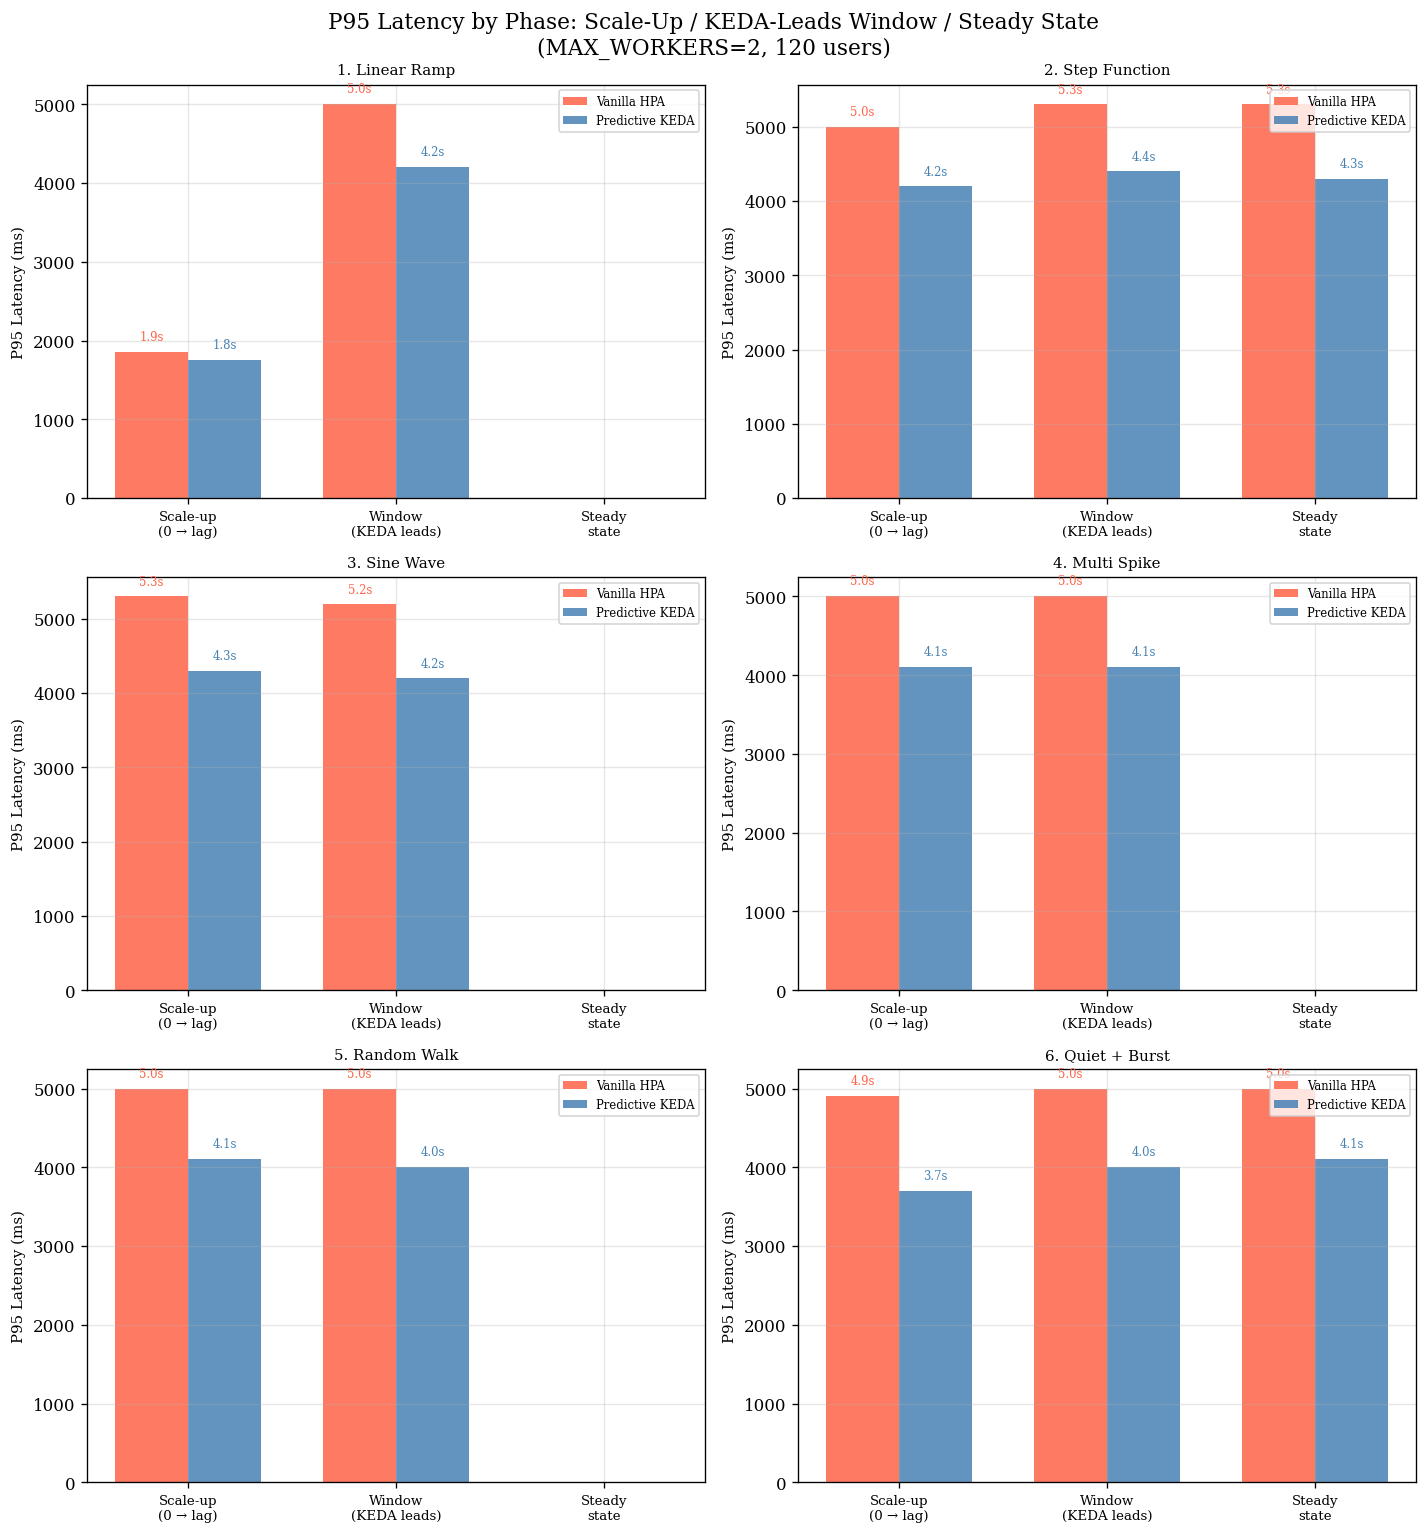

Saved: notebooks/mw2_phase_split_p95.png


In [88]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.flatten()

for i, name in enumerate(SCENARIO_NAMES):
    ax = axes[i]
    w  = find_advantage_window(name)
    dh = fetch_scenario(ROUND_HPA, name)
    mh = measure_scaleup_lag(dh['replicas'])
    _, act_h = slice_scenario(hist_hpa_raw,  name, ROUND_HPA)
    _, act_k = slice_scenario(hist_keda_raw, name, ROUND_KEDA)

    hpa_lag = mh['lag_s'] or 0
    win_s   = w['start'] if w['start'] is not None else hpa_lag
    win_e   = w['end']   if w['end']   is not None else hpa_lag

    phases = [
        ('Scale-up\n(0 → lag)',    0,     win_s),
        ('Window\n(KEDA leads)',   win_s, win_e),
        ('Steady\nstate',          win_e, 9999),
    ]

    h_meds, k_meds = [], []
    for _lbl, ps, pe in phases:
        hs = act_h[(act_h['t'] >= ps) & (act_h['t'] < pe)]
        ks = act_k[(act_k['t'] >= ps) & (act_k['t'] < pe)]
        h_meds.append(hs['95%'].median() if not hs.empty and hs['95%'].notna().any() else 0)
        k_meds.append(ks['95%'].median() if not ks.empty and ks['95%'].notna().any() else 0)

    x_pos = range(len(phases))
    w_bar = 0.35
    bh = ax.bar([xi - w_bar/2 for xi in x_pos], h_meds, w_bar,
                color=COLOR_HPA,  alpha=0.85, label=LABEL_HPA)
    bk = ax.bar([xi + w_bar/2 for xi in x_pos], k_meds, w_bar,
                color=COLOR_KEDA, alpha=0.85, label=LABEL_KEDA)

    for bars, color in [(bh, COLOR_HPA), (bk, COLOR_KEDA)]:
        for b in bars:
            h_val = b.get_height()
            if h_val > 200:
                ax.text(b.get_x() + b.get_width()/2, h_val + 150,
                        f'{h_val/1000:.1f}s', ha='center', fontsize=7, color=color)

    if w['start'] is None:
        ax.text(0.5, 0.92, 'No advantage window', transform=ax.transAxes,
                ha='center', fontsize=8, color='gray', style='italic')

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels([p[0] for p in phases], fontsize=8)
    ax.set_ylabel('P95 Latency (ms)')
    ax.set_title(name, fontsize=9)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)

fig.suptitle('P95 Latency by Phase: Scale-Up / KEDA-Leads Window / Steady State\n'
             '(MAX_WORKERS=2, 120 users)', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/mw2_phase_split_p95.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/mw2_phase_split_p95.png')

---
## 5 — Over-Provisioning

KEDA pre-scales before demand → higher mean replica count. This is the design trade-off:  
idle capacity now vs SLA violation later.

In [89]:
def mean_replicas(replicas_df: pd.DataFrame) -> float | None:
    if replicas_df.empty:
        return None
    df = replicas_df.copy().sort_values('sec').reset_index(drop=True)
    if len(df) < 2:
        return float(df['value'].iloc[0])
    dt = df['sec'].diff().fillna(0)
    return float(np.average(df['value'], weights=dt.clip(lower=0) + 1e-9))

op_rows = []
for name in SCENARIO_NAMES:
    dh = fetch_scenario(ROUND_HPA,  name)
    dk = fetch_scenario(ROUND_KEDA, name)
    h_mean = mean_replicas(dh['replicas'])
    k_mean = mean_replicas(dk['replicas'])
    h_max  = int(dh['replicas']['value'].max()) if not dh['replicas'].empty else None
    k_max  = int(dk['replicas']['value'].max()) if not dk['replicas'].empty else None
    ratio  = k_mean / h_mean if h_mean and k_mean else None
    op_rows.append({'Scenario': name,
                    'HPA_mean': h_mean, 'HPA_max': h_max,
                    'KEDA_mean': k_mean, 'KEDA_max': k_max,
                    'Ratio': ratio})

op_df = pd.DataFrame(op_rows)

print(f'{"Scenario":<22}  {"HPA Mean":>9}  {"HPA Max":>8}  {"KEDA Mean":>10}  {"KEDA Max":>9}  {"Ratio":>7}')
print('-' * 78)
for _, r in op_df.iterrows():
    ratio_str = f"{r['Ratio']:.2f}×" if r['Ratio'] else '—'
    print(f'{r["Scenario"]:<22}  {r["HPA_mean"]:>9.1f}  {str(r["HPA_max"]):>8}  '
          f'{r["KEDA_mean"]:>10.1f}  {str(r["KEDA_max"]):>9}  {ratio_str:>7}')
print('-' * 78)
h_ov = op_df['HPA_mean'].mean()
k_ov = op_df['KEDA_mean'].mean()
print(f'{"Overall":<22}  {h_ov:>9.1f}  {"—":>8}  {k_ov:>10.1f}  {"—":>9}  {k_ov/h_ov:>6.2f}×')

Scenario                 HPA Mean   HPA Max   KEDA Mean   KEDA Max    Ratio
------------------------------------------------------------------------------
1. Linear Ramp                3.0         4         8.7         15    2.91×
2. Step Function              2.6         5         5.2         15    2.01×
3. Sine Wave                  6.7        13        11.7         15    1.73×
4. Multi Spike                2.9         5         6.5         13    2.24×
5. Random Walk                5.0         9         8.2         15    1.65×
6. Quiet + Burst              1.3         2         1.5          3    1.19×
------------------------------------------------------------------------------
Overall                       3.6         —         7.0          —    1.95×


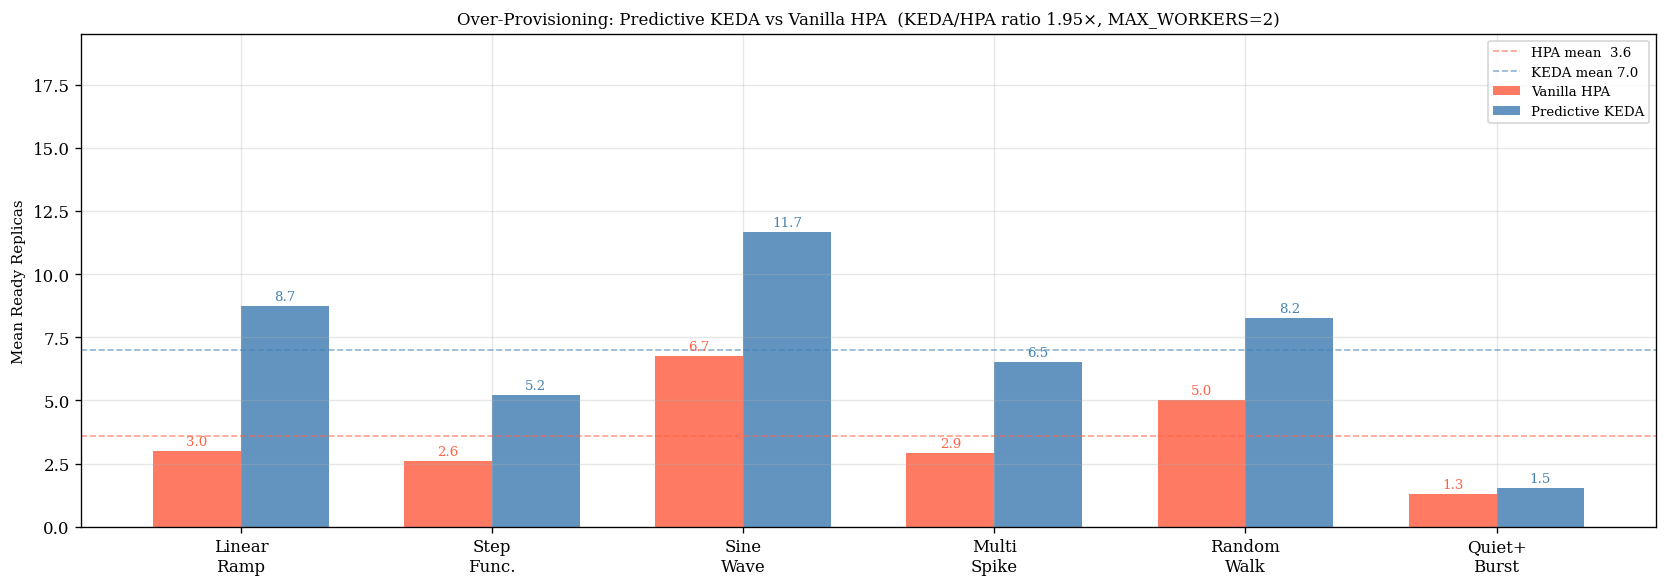

Saved: notebooks/mw2_overprovisioning.png


In [90]:
short = ['Linear\nRamp', 'Step\nFunc.', 'Sine\nWave', 'Multi\nSpike', 'Random\nWalk', 'Quiet+\nBurst']
x = np.arange(len(SCENARIO_NAMES))
w_bar = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_h = ax.bar(x - w_bar/2, op_df['HPA_mean'],  w_bar, label=LABEL_HPA,  color=COLOR_HPA,  alpha=0.85)
bars_k = ax.bar(x + w_bar/2, op_df['KEDA_mean'], w_bar, label=LABEL_KEDA, color=COLOR_KEDA, alpha=0.85)

for bar, color in [(bars_h, COLOR_HPA), (bars_k, COLOR_KEDA)]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.12,
                f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=8, color=color)

ax.axhline(h_ov, ls='--', lw=1, color=COLOR_HPA,  alpha=0.6, label=f'HPA mean  {h_ov:.1f}')
ax.axhline(k_ov, ls='--', lw=1, color=COLOR_KEDA, alpha=0.6, label=f'KEDA mean {k_ov:.1f}')

ax.set_xticks(x)
ax.set_xticklabels(short)
ax.set_ylabel('Mean Ready Replicas')
ax.set_title(f'Over-Provisioning: Predictive KEDA vs Vanilla HPA  '
             f'(KEDA/HPA ratio {k_ov/h_ov:.2f}×, MAX_WORKERS=2)')
ax.legend()
ax.set_ylim(0, max(op_df['HPA_max'].max(), op_df['KEDA_max'].max()) * 1.3)
plt.tight_layout()
plt.savefig('../notebooks/mw2_overprovisioning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/mw2_overprovisioning.png')

---
## 6 — Overall Summary

In [91]:
def summary_from_history(hist: pd.DataFrame) -> dict:
    """Compute aggregate stats from the clipped stats_history DataFrame.

    Uses only rows where Requests/s > 0.5 so idle-between-scenario rows
    (which are already excluded by clip_to_scenarios) don't dilute percentiles.
    The _stats.csv covers the full experiment run; this function is bounded
    to scenario windows only, consistent with all other per-scenario analyses.
    """
    active = hist[hist['Requests/s'] > 0.5].copy()
    total_req = int(hist['Requests/s'].sum())  # approx: Σ rps × 1s intervals
    fail_col  = next((c for c in hist.columns if 'Failure' in c and '/s' in c), None)
    total_fail = int(hist[fail_col].sum()) if fail_col else 0
    return {
        'Request Count':        total_req,
        'Failure Count':        total_fail,
        'Median Response Time': active['50%'].median(),
        'Average Response Time': active['50%'].mean(),  # approx (median of medians)
        '95%':                  active['95%'].median(),
        '99%':                  active['99%'].median(),
        'Max Response Time':    active['100%'].max(),
        'Requests/s':           active['Requests/s'].mean(),
    }

agg_h = summary_from_history(hist_hpa)
agg_k = summary_from_history(hist_keda)

print('=== Unified A/B (MAX_WORKERS=2, 120 users) — Overall Summary ===')
print('(stats derived from clipped scenario windows; idle pauses excluded)')
print(f'{"Metric":<28}  {"HPA":>14}  {"KEDA":>13}  {"Δ":>12}')
print('-' * 75)

metrics = [
    ('Total Requests (approx)', 'Request Count',        '{:.0f}',  False),
    ('Total Failures (approx)', 'Failure Count',        '{:.0f}',  False),
    ('Median (ms)',              'Median Response Time', '{:.0f}',  True),
    ('Avg (ms, approx)',         'Average Response Time','{:.0f}',  True),
    ('P95 (ms)',                 '95%',                 '{:.0f}',  True),
    ('P99 (ms)',                 '99%',                 '{:.0f}',  True),
    ('Max (ms)',                 'Max Response Time',   '{:.0f}',  True),
    ('Avg RPS',                  'Requests/s',          '{:.2f}',  False),
]

for label, col, fmt, show_delta in metrics:
    h_val = agg_h[col]
    k_val = agg_k[col]
    if show_delta:
        delta = f'{k_val - h_val:+.0f}ms ({(k_val-h_val)/h_val*100:+.0f}%)' if h_val else ''
    else:
        delta = f'{k_val - h_val:+.0f}' if not show_delta else ''
    print(f'{label:<28}  {fmt.format(h_val):>14}  {fmt.format(k_val):>13}  {delta:>12}')

print()
print('Saved figures:')
for f in sorted(Path('../notebooks').glob('mw2_*.png')):
    print(f'  notebooks/{f.name}')

=== Unified A/B (MAX_WORKERS=2, 120 users) — Overall Summary ===
(stats derived from clipped scenario windows; idle pauses excluded)
Metric                                   HPA           KEDA             Δ
---------------------------------------------------------------------------
Total Requests (approx)               126066         168976        +42910
Total Failures (approx)                    4              0            -4
Median (ms)                              590            230  -360ms (-61%)
Avg (ms, approx)                        1007            465  -542ms (-54%)
P95 (ms)                                5000           4100  -900ms (-18%)
P99 (ms)                                5400           5300  -100ms (-2%)
Max (ms)                                6800           6800    +0ms (+0%)
Avg RPS                                34.13          45.69           +12

Saved figures:
  notebooks/mw2_latency_bars.png
  notebooks/mw2_latency_boxplot.png
  notebooks/mw2_latency_p95.png
  not

---
## 7 — Scenario Shapes: Load Pattern Overview

Source: `notebooks/raw_data/data-1774627968260.csv` — Prometheus metrics (input_rps, input_cpu) from the  
training data collection session (`locustfile_training.py`, 2026-03-27, 3×6 scenarios shuffled, ORDER\_SEED=99).  
One representative run per scenario (first occurrence in the shuffled sequence).  
CPU utilisation = `input_cpu / 2.0` (2000m limit → ratio [0, 1]).

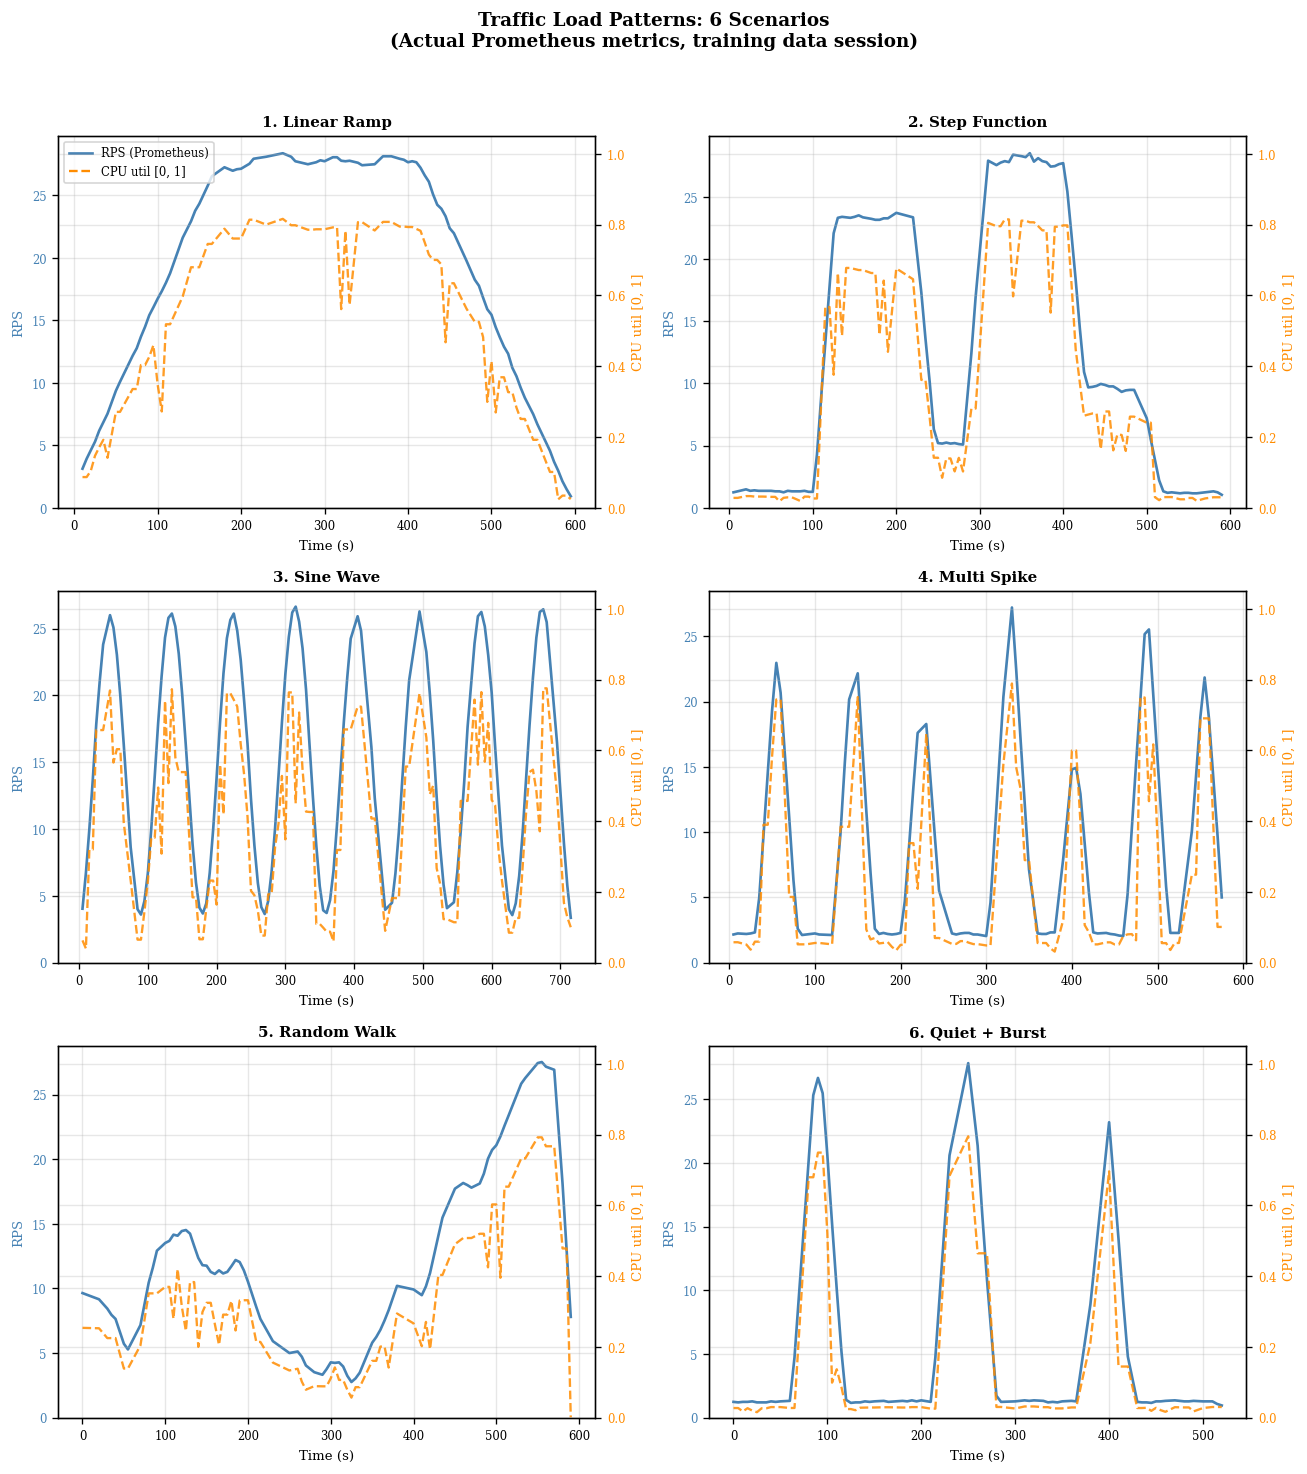

Saved: ../notebooks/mw2_scenario_shapes.png
Saved: ../thesis/figures/training_scenarios.png

1. Linear Ramp: 87 samples, 595s window
2. Step Function: 100 samples, 590s window
3. Sine Wave: 123 samples, 715s window
4. Multi Spike: 92 samples, 575s window
5. Random Walk: 84 samples, 590s window
6. Quiet + Burst: 75 samples, 520s window


In [92]:
import pandas as pd
from pathlib import Path

# ── Load large training dataset ────────────────────────────────────────────
raw2 = pd.read_csv(Path('../notebooks/raw_data/data-1774627968260.csv'))
raw2['ts'] = pd.to_datetime(raw2['ts'], utc=True)
raw2 = raw2.sort_values('ts').reset_index(drop=True)
raw2['t'] = (raw2['ts'] - raw2['ts'].iloc[0]).dt.total_seconds()

# ── Scenario windows ───────────────────────────────────────────────────────
# Reconstructed via ORDER_SEED=99 (locustfile_training.py) + cooldown detection.
# Each window is the first occurrence of that scenario in the shuffled sequence.
# ORDER: [Quiet+Burst, Sine Wave, Random Walk, Linear Ramp, Step Function, ...]
SCENARIO_WINDOWS_TRAIN = [
    ('1. Linear Ramp',   2210, 2805),   # rep 1, segment 4
    ('2. Step Function', 2930, 3520),   # rep 2, segment 5
    ('3. Sine Wave',      645, 1360),   # rep 3, segment 2  (720s)
    ('4. Multi Spike',   5220, 5795),   # rep 3, segment 8
    ('5. Random Walk',   1500, 2090),   # rep 2, segment 3
    ('6. Quiet + Burst',    0,  520),   # rep 2, segment 1
]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(11, 12))
axes = axes.flatten()
fig.suptitle(
    'Traffic Load Patterns: 6 Scenarios\n'
    '(Actual Prometheus metrics, training data session)',
    fontsize=11, fontweight='bold', y=1.02
)

COLOR_RPS = 'steelblue'
COLOR_CPU = 'darkorange'

for i, (name, t_start, t_end) in enumerate(SCENARIO_WINDOWS_TRAIN):
    ax  = axes[i]
    ax2 = ax.twinx()

    seg = raw2[(raw2['t'] >= t_start) & (raw2['t'] <= t_end)].copy()
    seg['t_rel'] = seg['t'] - t_start

    # RPS — left axis
    ax.plot(seg['t_rel'], seg['input_rps'],
            color=COLOR_RPS, lw=1.6)
    ax.set_ylabel('RPS', color=COLOR_RPS, fontsize=8)
    ax.tick_params(axis='y', labelcolor=COLOR_RPS, labelsize=7)
    ax.set_ylim(bottom=0)

    # CPU utilisation — right axis
    cpu_util = seg['input_cpu'] / 2.0
    ax2.plot(seg['t_rel'], cpu_util,
             color=COLOR_CPU, lw=1.4, alpha=0.85, linestyle='--')
    ax2.set_ylabel('CPU util [0, 1]', color=COLOR_CPU, fontsize=8)
    ax2.tick_params(axis='y', labelcolor=COLOR_CPU, labelsize=7)
    ax2.set_ylim(0, 1.05)

    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(True, alpha=0.3)

    if i == 0:
        lines = [
            Line2D([0], [0], color=COLOR_RPS, lw=1.6,              label='RPS (Prometheus)'),
            Line2D([0], [0], color=COLOR_CPU, lw=1.4, linestyle='--', label='CPU util [0,\u00a01]'),
        ]
        ax.legend(handles=lines, fontsize=7, loc='upper left')

fig.tight_layout()

out_nb     = Path('../notebooks/mw2_scenario_shapes.png')
out_thesis = Path('../thesis/figures/training_scenarios.png')
fig.savefig(out_nb,     dpi=150, bbox_inches='tight')
fig.savefig(out_thesis, dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', out_nb)
print('Saved:', out_thesis)
print()
for name, t_s, t_e in SCENARIO_WINDOWS_TRAIN:
    seg = raw2[(raw2['t'] >= t_s) & (raw2['t'] <= t_e)]
    print(f'{name}: {len(seg)} samples, {t_e-t_s:.0f}s window')
